<a href="https://colab.research.google.com/github/Sascha295/Datamining/blob/main/Copy_of_Final_Version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Air_Quality_20251108.csv to Air_Quality_20251108.csv


In [ ]:
import pandas as pd
import os
#importing database from device
print(os.listdir())  # check exact file name
df_raw = pd.read_csv('Air_Quality_20251108.csv')

['.config', 'Air_Quality_20251108.csv', 'clustered_regions.csv', 'sample_data']


In [ ]:
print(df.shape) #number of rows and cols

(18862, 12)


In [ ]:
df.head() #first 5 rows

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,878218,386,Ozone (O3),Mean,ppb,UHF42,402,West Queens,Summer 2023,06/01/2023,34.365989,NaN
1,876975,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,501,Port Richmond,Summer 2023,06/01/2023,11.331992,NaN
2,876900,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,207,East Flatbush - Flatbush,Summer 2023,06/01/2023,12.020333,NaN
3,877140,375,Nitrogen dioxide (NO2),Mean,ppb,CD,205,Fordham and University Heights (CD5),Summer 2023,06/01/2023,14.123178,NaN
4,874556,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF34,410,Rockaways,Summer 2023,06/01/2023,8.150637,NaN


issue: looking for invalid data types and missing values:

---

solution: using data info to show all attributes, number of values witha specific data type and whether or not they are null

---
Rationale: if some attributes have various data type numbers we have to unify them and if there are missing values we have to handle them


In [ ]:
df.info() #attributes, their data types and checking for null attributes
#checking for data type integrity:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18862 entries, 0 to 18861
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18862 non-null  int64  
 1   Indicator ID    18862 non-null  int64  
 2   Name            18862 non-null  object 
 3   Measure         18862 non-null  object 
 4   Measure Info    18862 non-null  object 
 5   Geo Type Name   18862 non-null  object 
 6   Geo Join ID     18862 non-null  int64  
 7   Geo Place Name  18862 non-null  object 
 8   Time Period     18862 non-null  object 
 9   Start_Date      18862 non-null  object 
 10  Data Value      18862 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ MB


all values are in correct data type.  

---
issue: messege col is null

---
sol: rop it without missing anything.

---
rationale: since all values are null we dont use any valuable info


In [ ]:
#dropping missing value and showing table after
 # Drop the 'message' column because it has 0 non-null values
df_raw = df_raw.drop(columns=['Message'])
df_raw.head(5)

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value
0,878218,386,Ozone (O3),Mean,ppb,UHF42,402,West Queens,Summer 2023,06/01/2023,34.365989
1,876975,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,501,Port Richmond,Summer 2023,06/01/2023,11.331992
2,876900,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,207,East Flatbush - Flatbush,Summer 2023,06/01/2023,12.020333
3,877140,375,Nitrogen dioxide (NO2),Mean,ppb,CD,205,Fordham and University Heights (CD5),Summer 2023,06/01/2023,14.123178
4,874556,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF34,410,Rockaways,Summer 2023,06/01/2023,8.150637


checking for other missing values:

In [ ]:
#check for missing Values
df.isna().sum()

,0
Unique ID,0
Indicator ID,0
Name,0
Measure,0
Measure Info,0
Geo Type Name,0
Geo Join ID,0
Geo Place Name,0
Time Period,0
Start_Date,0


issue and rationale: looking for duplicates. if objects are not in the same format the algorithm might treat duplicates as seperate objects. Sol:making sure all Data objects are in the same form (uppercase lowercse etc)

In [ ]:
 #unify forms for every attribut
df_raw.columns = df_raw.columns.str.strip().str.lower().str.replace(' ', '_')
text_cols = ['name','measure','measure_info','geo_type_name','geo_place_name','time_period']
for col in text_cols:
  df_raw[col] = df_raw[col].str.strip().str.lower() #all in lower case with the same format
df_raw['start_date'] = pd.to_datetime(df_raw['start_date'], errors='coerce')
df_raw['data_value'] = pd.to_numeric(df_raw['data_value'], errors='coerce') #Standard Date format
df_raw.head()

,unique_id,indicator_id,name,measure,measure_info,geo_type_name,geo_join_id,geo_place_name,time_period,start_date,data_value
0,878218,386,ozone (o3),mean,ppb,uhf42,402,west queens,summer 2023,2023-06-01,34.365989
1,876975,375,nitrogen dioxide (no2),mean,ppb,uhf42,501,port richmond,summer 2023,2023-06-01,11.331992
2,876900,375,nitrogen dioxide (no2),mean,ppb,uhf42,207,east flatbush - flatbush,summer 2023,2023-06-01,12.020333
3,877140,375,nitrogen dioxide (no2),mean,ppb,cd,205,fordham and university heights (cd5),summer 2023,2023-06-01,14.123178
4,874556,365,fine particles (pm 2.5),mean,mcg/m3,uhf34,410,rockaways,summer 2023,2023-06-01,8.150637


look for duplicates:

In [ ]:
#check for duplicates
print("Duplicates before:", df_raw.duplicated().sum())
df_raw = df_raw.drop_duplicates()
print("Duplicates after:", df_raw.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


Typo checking:

---
issue:looking for and correcting typos and wrong words in names

---
solution: get the number of each unique value for names

---
rationale:
it helps us to check if a value is a typo of another value

In [ ]:
# Check for typos/inconsistencies in 'name' (pollutant name)
print("\nUnique values and counts for 'name' (Pollutant Name):")
print(df_raw['name'].value_counts())
# Check for typos/inconsistencies in 'geo_place_name'
print("\nUnique values and counts for 'geo_place_name':")
print(df_raw['geo_place_name'].value_counts())
# Check for typos/inconsistencies in 'geo_type_name'
print("\nUnique values and counts for 'geo_type_name':")
print(df_raw['geo_type_name'].value_counts())
print("\n--- Reconfirming unique values for typo detection ---")
print("\nUnique values and counts for 'name' (Pollutant Name):")
print(df_raw['name'].value_counts())
print("\nUnique values and counts for 'geo_place_name':")
print(df_raw['geo_place_name'].value_counts())
print("\nUnique values and counts for 'geo_type_name':")
print(df_raw['geo_type_name'].value_counts())


Unique values and counts for 'name' (Pollutant Name):
name
nitrogen dioxide (no2)                                    6345
fine particles (pm 2.5)                                   6345
ozone (o3)                                                2115
asthma hospitalizations due to ozone                       480
asthma emergency departments visits due to ozone           480
asthma emergency department visits due to pm2.5            480
annual vehicle miles traveled (trucks)                     321
annual vehicle miles traveled                              321
annual vehicle miles traveled (cars)                       321
deaths due to pm2.5                                        240
cardiac and respiratory deaths due to ozone                240
cardiovascular hospitalizations due to pm2.5 (age 40+)     240
respiratory hospitalizations due to pm2.5 (age 20+)        240
outdoor air toxics - formaldehyde                          203
outdoor air toxics - benzene                              

No typo detected in dataset since all unique values have a number of occurance and no values is the typo of the other

checking for logical consistency:

---
issue: wrong and illogical data

---

check for these in the dataset:
 1. impossible values(Domain constraints): negative pollution start date and period of time not matching, pollution exceeding the
 (NAAQS) standards, geo_ID does not belong to NY
2. logical relationships in the dataset: year mean cannot be smaller than both summer and winter mean for that year. The
 neighborhood mean is so much different from city wide mean



In [ ]:
import pandas as pd
import re

# --- Make sure all column names are lowercase and stripped ---
df_raw.columns = df_raw.columns.str.strip().str.lower()

# --- Standardize underscores (optional but recommended) ---
df_raw.columns = df_raw.columns.str.replace(' ', '_')

# Now you’ll have columns like:
# ['unique_id', 'indicator_id', 'name', 'measure', 'measure_info',
#  'geo_type_name', 'geo_join_id', 'geo_place_name',
#  'time_period', 'start_date', 'data_value']

# --- Convert datatypes ---
df_raw['start_date'] = pd.to_datetime(df_raw['start_date'], errors='coerce')
df_raw['data_value'] = pd.to_numeric(df_raw['data_value'], errors='coerce')

# --- Define NAAQS approximate annual standards ---
naaqs_standards = {
    'nitrogen dioxide (no2)': {'unit': 'ppb', 'annual_limit': 53},     # Annual mean
    'fine particles (pm 2.5)': {'unit': 'mcg/m3', 'annual_limit': 12}, # Annual mean
    'ozone (o3)': {'unit': 'ppb', 'annual_limit': 70}                  # 8-hour max reference
}

# --- Detect suspiciously high values (10× NAAQS) ---
suspicious_outliers = pd.DataFrame()

# Lowercase pollutant names for matching
df_raw['name'] = df_raw['name'].str.lower()

for pollutant, details in naaqs_standards.items():
    pollutant_df = df_raw[df_raw['name'] == pollutant].copy()

    threshold_10x = details['annual_limit'] * 10
    exceeding_values = pollutant_df[pollutant_df['data_value'] > threshold_10x]

    if not exceeding_values.empty:
        print(f"\nValues exceeding 10× NAAQS for {pollutant.upper()} (>{threshold_10x} {details['unit']}):")
        display(exceeding_values[['name', 'measure_info', 'data_value', 'geo_place_name', 'time_period']].head())
        suspicious_outliers = pd.concat([suspicious_outliers, exceeding_values])
    else:
        print(f"\nNo values exceeding 10× NAAQS for {pollutant.upper()} (>{threshold_10x} {details['unit']})")

# --- Logical consistency checks ---

# 1ⁱ Compare 'start_date' vs 'time_period' year
df_raw['year_from_date'] = df_raw['start_date'].dt.year

def extract_year(time_period_str):
    match = re.search(r'\b(\d{4})\b', str(time_period_str))
    return int(match.group(1)) if match else None

df_raw['year_from_time_period'] = df_raw['time_period'].apply(extract_year)

print("\nConsistency between year_from_date and year_from_time_period:")
print((df_raw['year_from_date'] == df_raw['year_from_time_period']).value_counts())
print("\nSample of inconsistent dates:")
display(df_raw[df_raw['year_from_date'] != df_raw['year_from_time_period']].head())

# 2ⁱ Check for negative pollutant values
print("\nNegative pollutant count:")
print((df_raw['data_value'] < 0).sum())


No values exceeding 10× NAAQS for NITROGEN DIOXIDE (NO2) (>530 ppb)

No values exceeding 10× NAAQS for FINE PARTICLES (PM 2.5) (>120 mcg/m3)

No values exceeding 10× NAAQS for OZONE (O3) (>700 ppb)

Consistency between year_from_date and year_from_time_period:
True     16888
False     1974
Name: count, dtype: int64

Sample of inconsistent dates:


,unique_id,indicator_id,name,measure,measure_info,geo_type_name,geo_join_id,geo_place_name,time_period,start_date,data_value,year_from_date,year_from_time_period
8133,412768,375,nitrogen dioxide (no2),mean,ppb,cd,313,coney island (cd13),annual average 2016,2015-12-31,14.64,2015,2016
8134,412600,375,nitrogen dioxide (no2),mean,ppb,uhf34,301,washington heights,annual average 2016,2015-12-31,19.85,2015,2016
8135,410821,365,fine particles (pm 2.5),mean,mcg/m3,uhf42,401,long island city - astoria,annual average 2016,2015-12-31,8.65,2015,2016
8136,412531,375,nitrogen dioxide (no2),mean,ppb,uhf42,407,southwest queens,annual average 2016,2015-12-31,17.80,2015,2016
8137,412471,375,nitrogen dioxide (no2),mean,ppb,uhf42,208,canarsie - flatlands,annual average 2016,2015-12-31,15.30,2015,2016



Negative pollutant count:
0


issue was: start date and perod time do not match in 1974 cases

---
sol: we sampled a table from these 1974 cases and understood this is not inconssitant

---
rationale: The sample shows the start date for data collection was 2015/12, and the year this data applies to is 2016. our code just extracted the date
 to measure if time period is consistent with start year. even though 1974 records in our code turned out to be inconsistant, when we look
 closer in samples, we see it is logical that data collected from December 2015 will be used for th year 2016.

Outilier detection:
issue: finding the most apropraite way to detect outliers

---
solution: first visually analyze the dataset via a blackBox

---
Rationale: it helps to understand if dataset is normally distributed or skewd

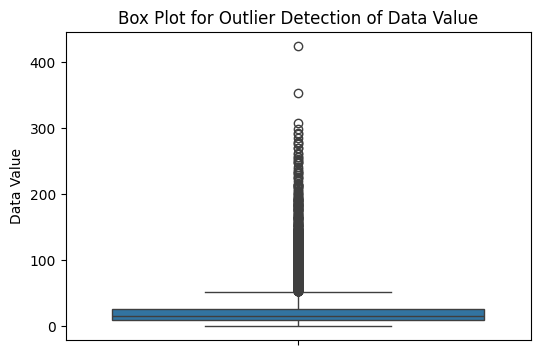

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['data_value'])


plt.title('Box Plot for Outlier Detection of Data Value')
plt.ylabel('Data Value')
plt.show()

issue: data is right skewed

---
sol: use Interquartile Range (IQR) Method to detect the number of outliers in dataset

---
rationale: this method is suited for skewed data and is generally the most reliable one


Total number of outliers detected using IQR method: 990
Lower bound: -17.55, Upper bound: 52.56


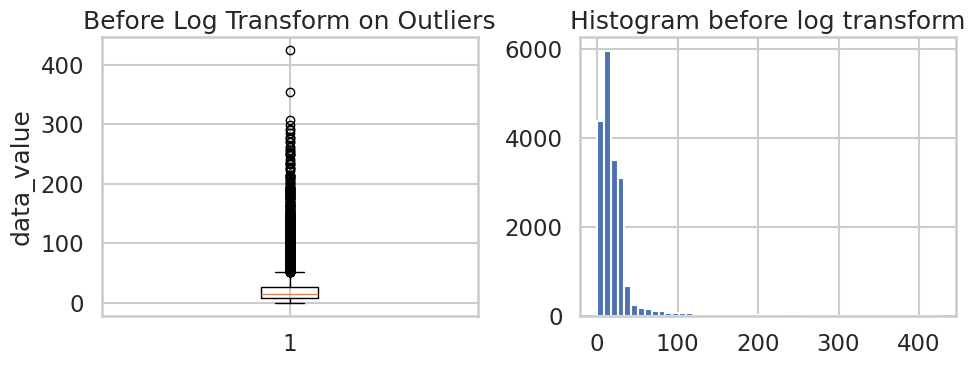

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#this library is used for visualization
# Calculate IQR
Q1 = df_raw['data_value'].quantile(0.25)
Q3 = df_raw['data_value'].quantile(0.75)
IQR = Q3 - Q1

# Defineing outlier threshold
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detecting outliers
outliers = df_raw[(df_raw['data_value'] < lower_bound) | (df_raw['data_value'] > upper_bound)]
num_outliers = outliers.shape[0]

print(f"Total number of outliers detected using IQR method: {num_outliers}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

# visualizeing again

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.boxplot(df_raw['data_value'], vert=True)
plt.title('Before Log Transform on Outliers')
plt.ylabel('data_value')

plt.subplot(1,2,2)
df_raw['data_value'].hist(bins=50)
plt.title('Histogram before log transform')
plt.tight_layout()
plt.show()

Interpretation:
this method flags high values as outliers and many of them might be real values. it provides a high number of outliers because it looks for high values not just unusal patterns

issue: too many outliers detected

---
solution: use another outlier detection method to comfirm:
isolation forecasting
---
Rationale: isolation is an adoptive algorithm and is suitable for skewed datasets. we can comfirm the results of both methods to handle the outliers


Number of outliers detected by Isolation Forest: 472


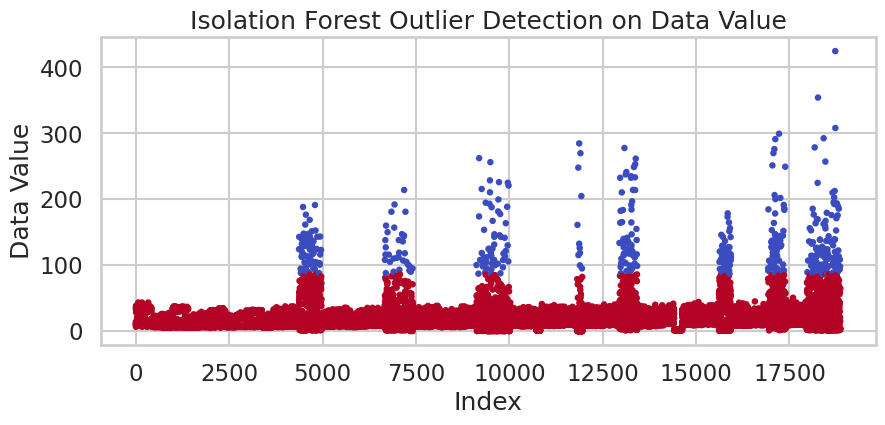


Outlier value range:
count    472.000000
mean     134.737032
std       47.145148
min       86.996313
25%      102.499673
50%      120.126850
75%      146.825000
max      424.700000
Name: data_value, dtype: float64


In [ ]:
# --- Import required libraries ---
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# --- Ensure the key column is numeric ---
df_raw['data_value'] = pd.to_numeric(df_raw['data_value'], errors='coerce')

# --- Initialize Isolation Forest model ---
# contamination ≈ expected proportion of outliers in dataset (tune between 0.01–0.05)
iso = IsolationForest(
    n_estimators=100,
    contamination=0.025,   # ≈ 2.5% of data expected to be outliers
    random_state=42
)

# --- Fit model and predict anomalies ---
df_raw['iso_flag'] = iso.fit_predict(df_raw[['data_value']])

# In IsolationForest:
#   -1  → outlier (anomaly)
#    1  → normal

# --- Extract detected outliers ---
iso_outliers = df_raw[df_raw['iso_flag'] == -1]
print(f"Number of outliers detected by Isolation Forest: {len(iso_outliers)}")

# --- Optional: visualize the results ---
plt.figure(figsize=(10, 4))
plt.scatter(df_raw.index, df_raw['data_value'], c=df_raw['iso_flag'], cmap='coolwarm', s=10)
plt.title('Isolation Forest Outlier Detection on Data Value')
plt.xlabel('Index')
plt.ylabel('Data Value')
plt.show()

# --- Optional summary statistics ---
print("\nOutlier value range:")
print(iso_outliers['data_value'].describe())

issue: The number of outliers is different for each method

---
sol: finding common outliers between them

---
Rationale: The model will be more reliable if we see many overlaps between two approaches, it means these common outliers are truly extrem and unsual



In [ ]:
import numpy as np

# Compute IQR thresholds
Q1 = df_raw['data_value'].quantile(0.25)
Q3 = df_raw['data_value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Isolation Forest
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.025, random_state=42)
df_raw['iso_flag'] = iso.fit_predict(df_raw[['data_value']])

# Find common outliers
is_iqr = (df_raw['data_value'] < lower_bound) | (df_raw['data_value'] > upper_bound)
is_iso = df_raw['iso_flag'] == -1
df_raw['common_outlier'] = is_iqr & is_iso

print(f"Common outliers before log transform: {df_raw['common_outlier'].sum()}")

# Apply log transform ONLY to those common outliers
df_raw.loc[df_raw['common_outlier'], 'data_value'] = np.log1p(df_raw.loc[df_raw['common_outlier'], 'data_value'])

print("✅ Log transform applied to common outliers only.")

Common outliers before log transform: 472
✅ Log transform applied to common outliers only.


issues: how to handle the outliers

---
sol: applying log function to common outliers between two methods

---
Rationale: log functions compresses outliers but keeps the relational order between them. it is suitable for environment data



Visual representation of data after applying log:

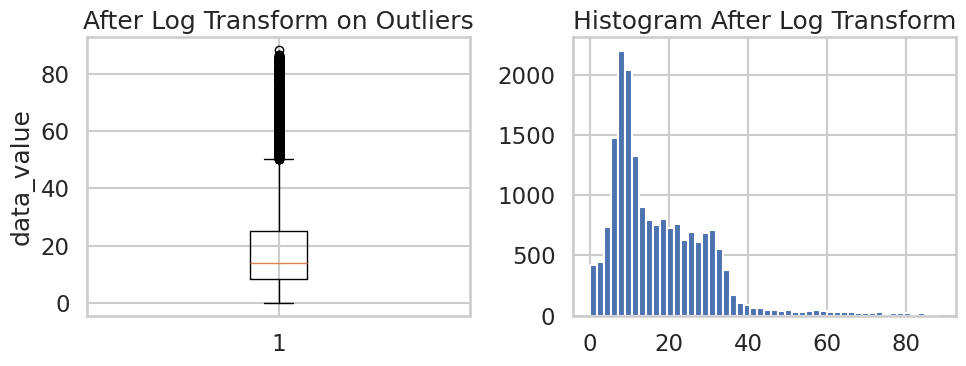

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.boxplot(df_raw['data_value'], vert=True)
plt.title('After Log Transform on Outliers')
plt.ylabel('data_value')

plt.subplot(1,2,2)
df_raw['data_value'].hist(bins=50)
plt.title('Histogram After Log Transform')
plt.tight_layout()
plt.show()

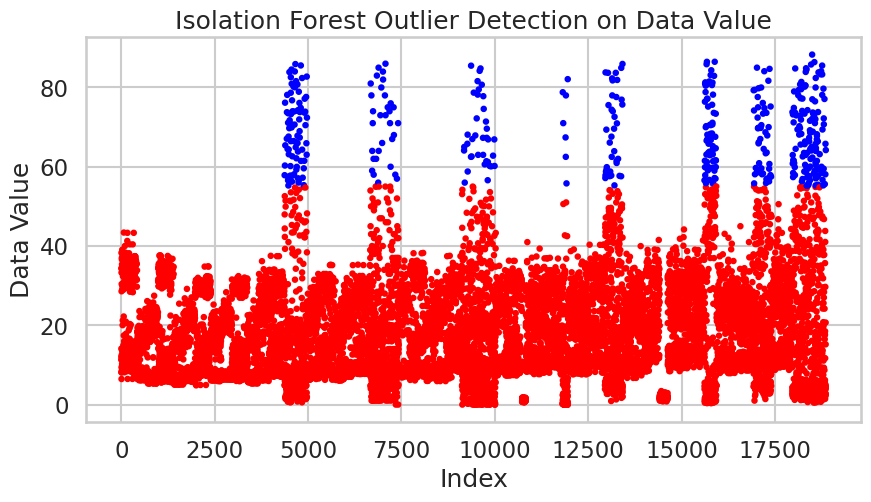

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import pandas as pd

# Ensure column is numeric
df_raw['data_value'] = pd.to_numeric(df_raw['data_value'], errors='coerce')

# Run Isolation Forest
iso = IsolationForest(contamination=0.025, random_state=42)
df_raw['iso_flag'] = iso.fit_predict(df_raw[['data_value']])

# Plot results
plt.figure(figsize=(10,5))
plt.scatter(df_raw.index, df_raw['data_value'],
            c=df_raw['iso_flag'].map({1:'red', -1:'blue'}),
            s=10)
plt.title('Isolation Forest Outlier Detection on Data Value')
plt.xlabel('Index')
plt.ylabel('Data Value')
plt.show()

As seen in chart the outliers are compressed and data is less skewed.

2.Preprocessing:
1. attribute transformation: Log transformation is already done to handle the outliers and compress the skewed data
2. feature selection: selecting relevant values for clustering and classification
3. scaling: different formats and units for numerical values. since our goal is to cluster numerical values we scale them based on natural distance and varience => z score standardization
4. clustering of pollutants( NO₂, PM₂.₅, O₃,) => unsupervised stage to find the natural patterns and groups
5. one hot coding +  preparing data for classification
6. classification => supervised stage with ready labels

a representation of data for feature selection:

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---- CLEAN TABLE OF POLLUTANTS & THEIR COUNTS ----
feature_counts = (
    df_raw['name']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'Pollutant', 'name': 'Count'})
)

# Display clean styled table
display(
    feature_counts.style.set_caption("Pollutant Frequency Table")
                        .set_table_styles(
                            [{'selector': 'caption',
                              'props': [('font-size', '16px'),
                                        ('font-weight', 'bold'),
                                        ('text-align', 'center')]}]

SyntaxError: incomplete input (ipython-input-4114897868.py, line 20)

As shown in the table, physical pollutants conduct the majority of the measures

/tmp/ipython-input-790725257.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


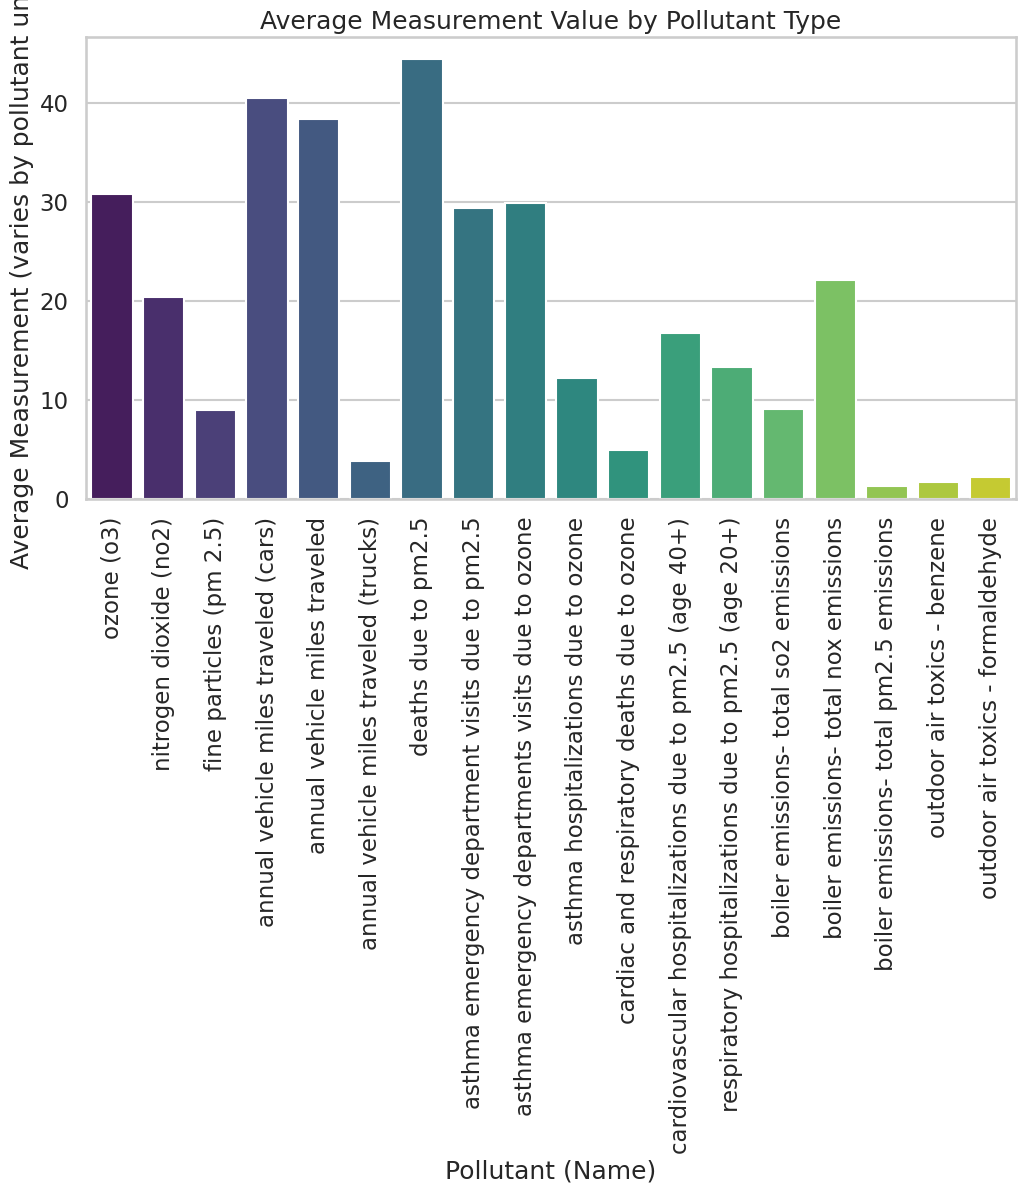

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
data=df_raw,
x='name',
y='data_value',
estimator='mean',
 errorbar=None,
hue='name',
palette='viridis',
legend=False
 )
plt.xticks(rotation=90)
plt.title('Average Measurement Value by Pollutant Type')
plt.xlabel('Pollutant (Name)')
plt.ylabel('Average Measurement (varies by pollutant unit)')
plt.tight_layout()
plt.show()

This chart can only represent different categories of pollutant but the units are different so we cannot numerically compare them.

dividing data values into 3 sets so we can have a more meaningful interpretation
(if we just scale the data blindly we are mixing up values that must be understood differently, we cannot compare number of hospitalizations of one pollutant with number of another physical pollutants )

---
1. physical pollutant values:

---

2. health impact measure of values

---
3. traffic and emission impact measure of values



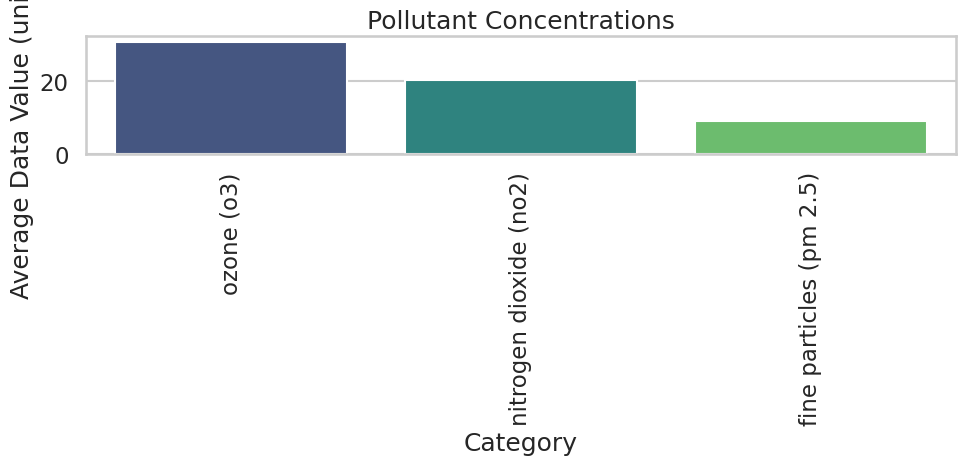

/tmp/ipython-input-3717306451.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


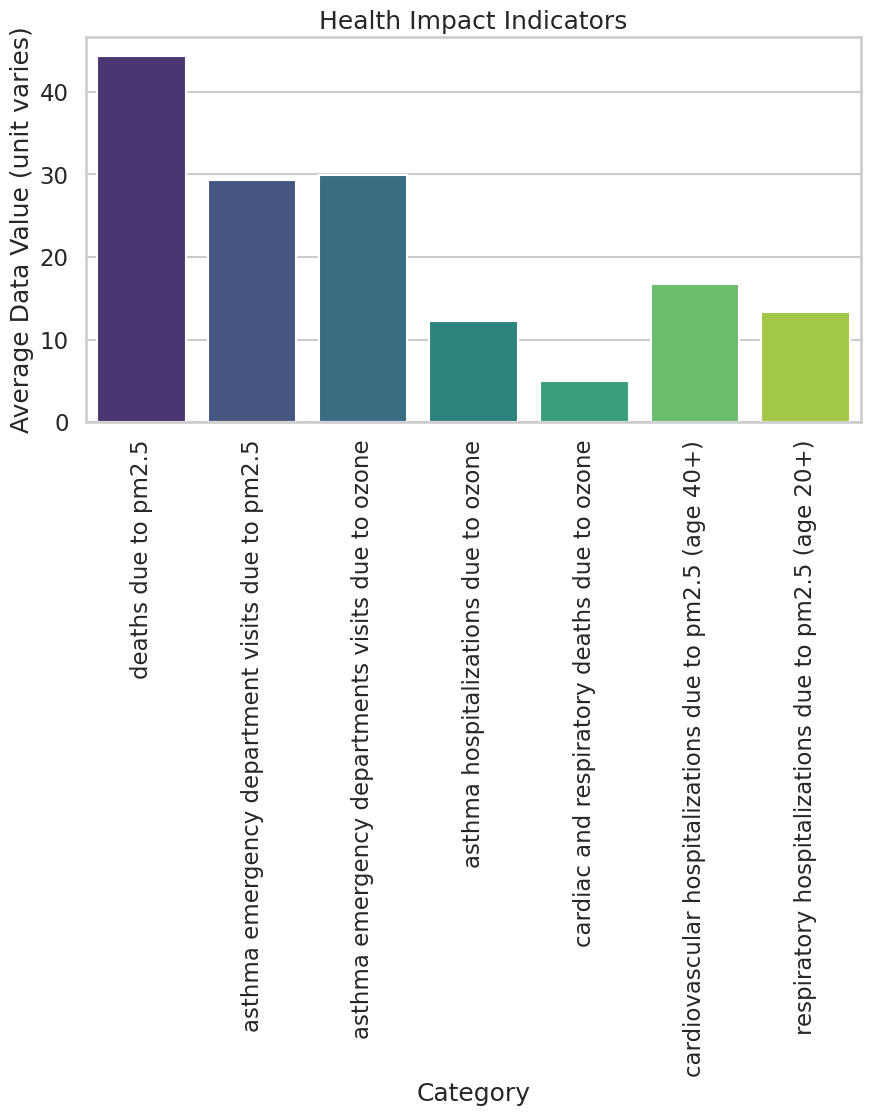

/tmp/ipython-input-3717306451.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


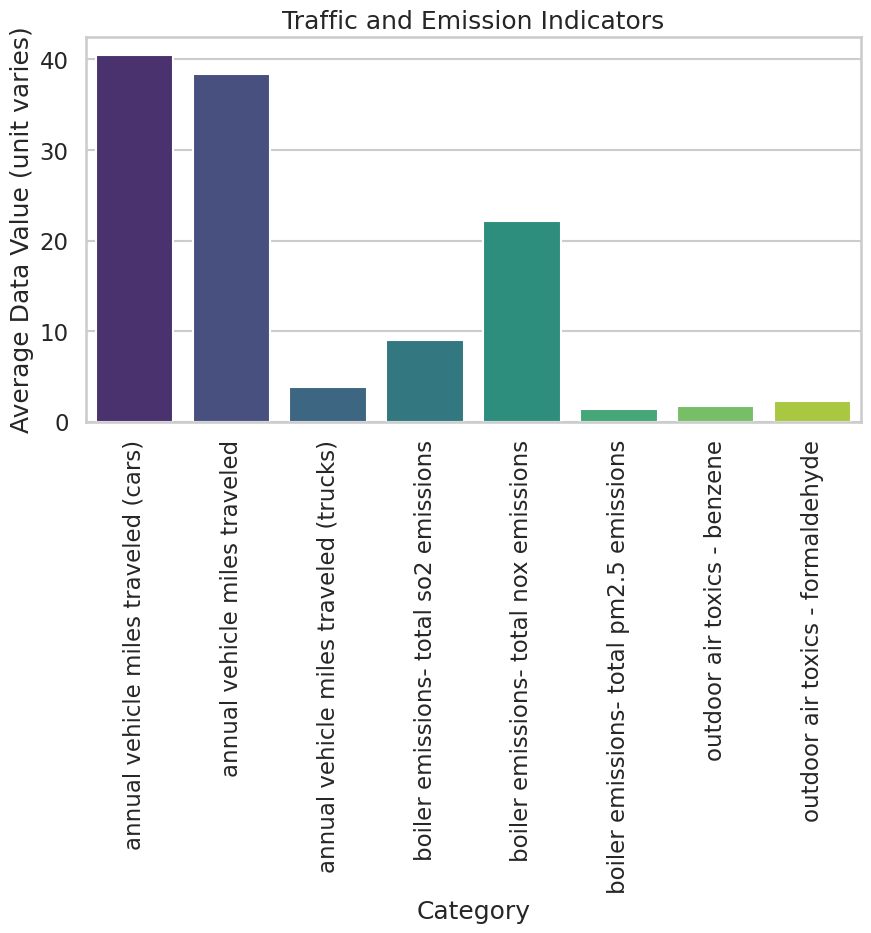

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define groups
pollutants = ['nitrogen dioxide (no2)', 'fine particles (pm 2.5)', 'ozone (o3)']
health = [n for n in df_raw['name'].unique() if 'asthma' in n or 'death' in n or 'hospitalization' in n]
traffic = [n for n in df_raw['name'].unique() if 'vehicle' in n]
emissions = [n for n in df_raw['name'].unique() if 'boiler' in n or 'emission' in n or 'toxic' in n]

def plot_group(names, title):
    temp = df_raw[df_raw['name'].isin(names)]
    plt.figure(figsize=(10,5))
    sns.barplot(
        data=temp,
        x='name',
        y='data_value',
        estimator='mean',
        errorbar=None,
        hue='name',
        palette='viridis',
        legend=False
    )
    plt.xticks(rotation=90)
    plt.title(title)
    plt.xlabel('Category')
    plt.ylabel('Average Data Value (unit varies)')
    plt.tight_layout()
    plt.show()

# Plot each group
plot_group(pollutants, 'Pollutant Concentrations')
plot_group(health, 'Health Impact Indicators')
plot_group(traffic + emissions, 'Traffic and Emission Indicators')

This gives us 3 subjest of discussion. now lets focus on physical pollutants:

checking for Temporal coverage to help us select the values with the beset data coverage:


Unique years in filtered data (Annual Average): [2023 2022 2021 2020 2019 2018 2017 2015 2013 2012 2011 2010 2009 2008]


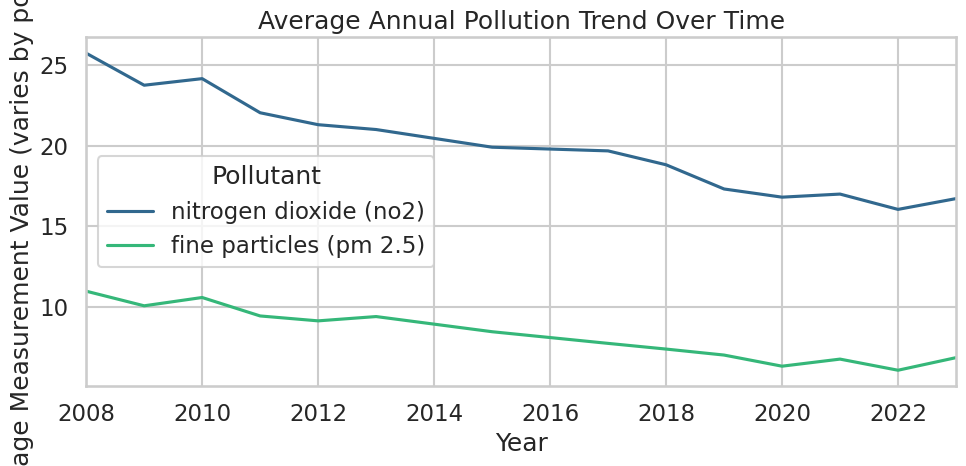

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'start_date' is in datetime format for plotting
df_raw['start_date'] = pd.to_datetime(df_raw['start_date'], errors='coerce')

df_raw['year'] = df_raw['start_date'].dt.year

# Filter data for selected pollutants and only include 'annual average' time periods
plot_df = df_raw[
    df_raw['name'].isin(['ozone (o3)', 'nitrogen dioxide (no2)', 'fine particles (pm 2.5)']) &
    df_raw['time_period'].str.contains('annual average', case=False, na=False)
].copy()

# Print unique years in the filtered data to diagnose
print("Unique years in filtered data (Annual Average):", plot_df['year'].unique())


plt.figure(figsize=(10,5))
sns.lineplot(
    data=plot_df,
    x='year',
    y='data_value',
    hue='name',
    estimator='mean',
    errorbar=None, # Use errorbar instead of ci
    palette='viridis'
)

# Set x-axis limits to cover the full range of years (2005-2023)
plt.xlim(plot_df['year'].min(), plot_df['year'].max()) # Set limits based on available annual data
plt.xticks(range(plot_df['year'].min(), plot_df['year'].max() + 1, 2)) # Add ticks for every other year for better readability


plt.title('Average Annual Pollution Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Average Measurement Value (varies by pollutant)')
plt.legend(title='Pollutant')
plt.tight_layout()
plt.show()

Note: The trends for Nitrogen dioxide (NO2), and Fine particles (PM 2.5) are shown starting from 2008 because data for these specific pollutants is consistently available in this dataset from that year onwards. The dataset includes also does not include the annual year trend for Ozone (O3) as that air quality indicators is usually measured during the summer.

In [ ]:
import pandas as pd

# Define the indicator groups
pollutants = ['ozone (o3)', 'nitrogen dioxide (no2)', 'fine particles (pm 2.5)']
health = [n for n in df_raw['name'].unique() if 'asthma' in n or 'death' in n or 'hospitalization' in n]
traffic_emissions = [n for n in df_raw['name'].unique() if 'vehicle' in n or 'boiler' in n or 'emission' in n or 'toxic' in n]

# Combine all groups for iteration
all_indicator_groups = {
    "Physical Pollutants": pollutants,
    "Health Outcome Indicators": health,
    "Traffic and Emission Indicators": traffic_emissions
}

# Ensure 'start_date' is in datetime format and 'year' column exists
if 'start_date' not in df_raw.columns or not pd.api.types.is_datetime64_any_dtype(df_raw['start_date']):
    df_raw['start_date'] = pd.to_datetime(df_raw['start_date'], errors='coerce')
if 'year' not in df_raw.columns:
    df_raw['year'] = df_raw['start_date'].dt.year

print("Indicator Details (Year Range, Data Value Count, Time Period Variations, Missing Values):")
print("---------------------------------------------------------------------------------------")

for group_name, indicator_group in all_indicator_groups.items():
    print(f"\n--- {group_name} ---")
    for indicator in indicator_group:
        # Filter data for the current indicator
        indicator_df = df_raw[df_raw['name'] == indicator].copy()

        if not indicator_df.empty:
            min_year = indicator_df['year'].min()
            max_year = indicator_df['year'].max()
            data_count = indicator_df.shape[0] # Get the number of rows
            unique_time_periods = indicator_df['time_period'].unique().tolist() # Get unique time periods
            missing_data_count = indicator_df['data_value'].isnull().sum() # Count missing data values

            print(f"- {indicator.title()}:")
            print(f"  - Data available from {min_year} to {max_year}")
            print(f"  - Total data values: {data_count}")
            print(f"  - Time period variations: {unique_time_periods}")
            if missing_data_count > 0:
                print(f"  - Missing 'data_value' entries: {missing_data_count}")
            else:
                print(f"  - No missing 'data_value' entries.")
        else:
            print(f"- {indicator.title()}: No data found.")

Indicator Details (Year Range, Data Value Count, Time Period Variations, Missing Values):
---------------------------------------------------------------------------------------

--- Physical Pollutants ---
- Ozone (O3):
  - Data available from 2009 to 2023
  - Total data values: 2115
  - Time period variations: ['summer 2023', 'summer 2022', 'summer 2021', 'summer 2020', 'summer 2019', 'summer 2018', 'summer 2017', 'summer 2016', 'summer 2015', 'summer 2014', 'summer 2013', 'summer 2012', 'summer 2011', 'summer 2010', 'summer 2009']
  - No missing 'data_value' entries.
- Nitrogen Dioxide (No2):
  - Data available from 2008 to 2023
  - Total data values: 6345
  - Time period variations: ['summer 2023', 'annual average 2023', 'winter 2022-23', 'summer 2022', 'annual average 2022', 'winter 2021-22', 'summer 2021', 'annual average 2021', 'winter 2020-21', 'summer 2020', 'annual average 2020', 'winter 2019-20', 'summer 2019', 'annual average 2019', 'winter 2018-19', 'summer 2018', 'annual 

Average Annual Pollution Values per Pollutant and Year:


year,2008,2009,2010,2011,2012,2013,2015,2017,2018,2019,2020,2021,2022,2023
name,,,,,,,,,,,,,,
fine particles (pm 2.5),10.977801,10.069574,10.585390,9.440071,9.135248,9.402199,8.460852,7.737801,7.384326,7.012553,6.321702,6.761250,6.070837,6.851945
nitrogen dioxide (no2),25.748936,23.760284,24.169078,22.051418,21.310709,21.010567,19.913780,19.684823,18.822766,17.320638,16.812979,17.004124,16.053687,16.722663


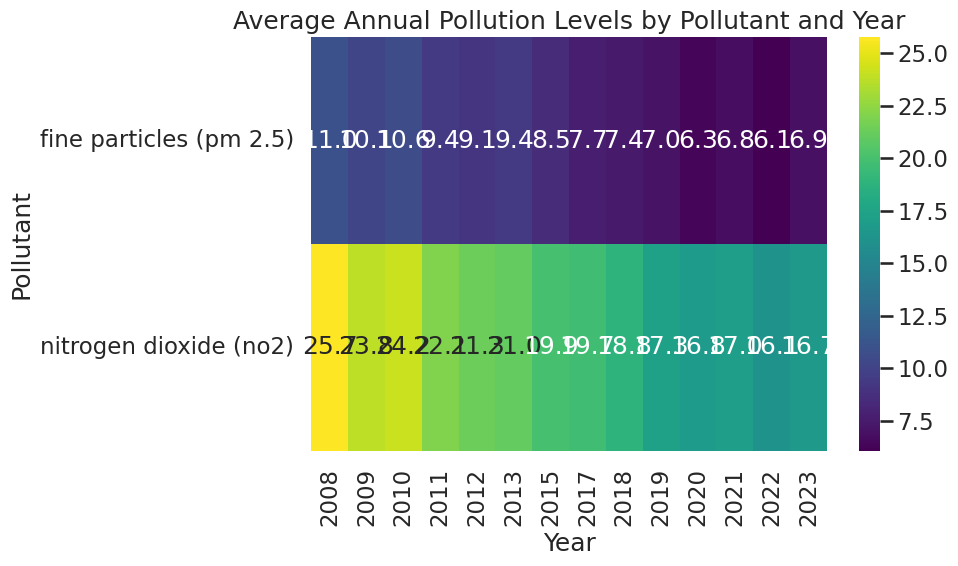

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Filter data for selected pollutants and include only 'annual average' time periods
annual_avg_data = df_raw[
    df_raw['name'].isin(['ozone (o3)', 'nitrogen dioxide (no2)', 'fine particles (pm 2.5)']) &
    df_raw['time_period'].str.contains('annual average', case=False, na=False)
].copy()

# Calculate the mean data_value for each pollutant and year
heatmap_data = annual_avg_data.groupby(['name', 'year'])['data_value'].mean().unstack()

# Display the calculated mean values
print("Average Annual Pollution Values per Pollutant and Year:")
display(heatmap_data)

# Generate the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="viridis")

plt.title('Average Annual Pollution Levels by Pollutant and Year')
plt.xlabel('Year')
plt.ylabel('Pollutant')
plt.tight_layout()
plt.show()

**Note:** The annual average heatmap does not include Ozone (O3) because the dataset does not contain entries with 'annual average' in the 'Time Period' for this pollutant.

Sample of Seasonal Trends Data:


,name,year,season,data_value
0,fine particles (pm 2.5),2008,Winter,13.557234
1,fine particles (pm 2.5),2009,Summer,11.103191
2,fine particles (pm 2.5),2009,Winter,10.421631
3,fine particles (pm 2.5),2010,Summer,12.206099
4,fine particles (pm 2.5),2010,Winter,13.171206



Unique seasons found in the filtered data:
['Winter' 'Summer']

Average Summer Pollution Values per Pollutant and Year:


year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
name,,,,,,,,,,,,,,,
fine particles (pm 2.5),11.103191,12.206099,11.785177,10.660000,10.559433,8.988227,9.762332,8.458369,9.383546,8.689078,8.305674,7.167660,8.621313,6.736269,8.988542
nitrogen dioxide (no2),22.075248,20.425248,19.906879,18.328014,17.654610,16.226312,15.736261,15.190213,15.399149,14.240071,14.676667,12.134539,12.631037,11.923448,13.202019
ozone (o3),24.762979,32.439291,31.818794,32.921348,30.037234,30.451631,30.910906,32.975532,28.791277,29.924681,29.646312,29.728794,29.735170,33.149042,34.440996


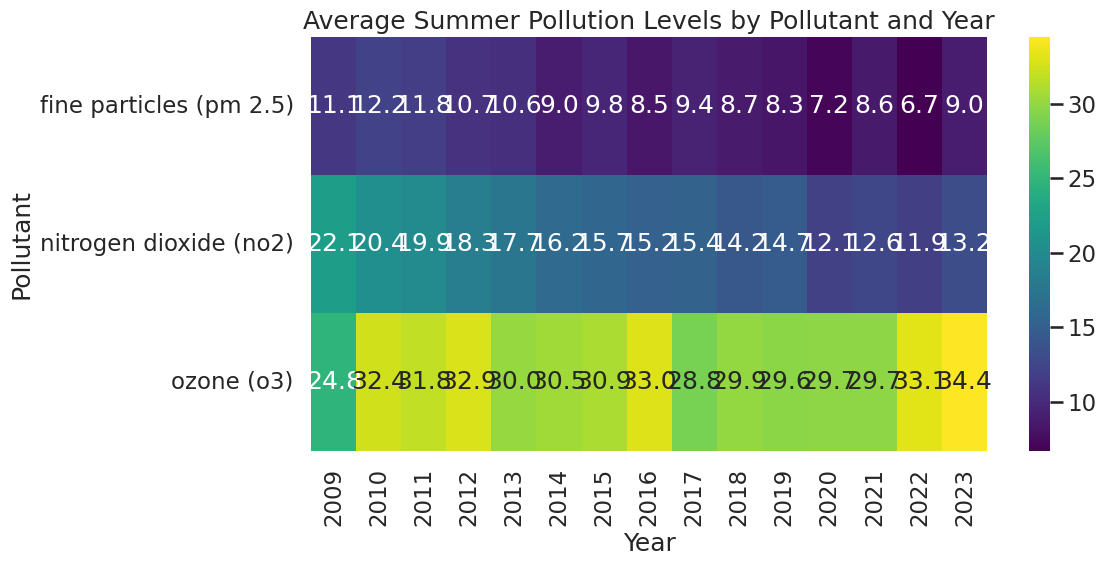

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Import mdates


# Data Cleaning and Standardization (from previous successful steps)
df_raw.columns = df_raw.columns.str.strip().str.lower().str.replace(' ', '_')
text_cols = ['name','measure','measure_info','geo_type_name','geo_place_name','time_period']
for col in text_cols:
  df_raw[col] = df_raw[col].str.strip().str.lower() #all in lower case with the same format

# Convert date and numeric columns
df_raw['start_date'] = pd.to_datetime(df_raw['start_date'], errors='coerce')
df_raw['data_value'] = pd.to_numeric(df_raw['data_value'], errors='coerce') #Standard Date format

# Drop the 'message' column if it exists and is all null
if 'message' in df_raw.columns and df_raw['message'].isnull().all():
    df_raw = df_raw.drop(columns=['message'])


# Ensure 'start_date' is in datetime format and 'year' column exists
df_raw['start_date'] = pd.to_datetime(df_raw['start_date'], errors='coerce')
df_raw['year'] = df_raw['start_date'].dt.year

# Function to extract season from 'Time Period'
def get_season(time_period):
    if isinstance(time_period, str):
        time_period_lower = time_period.lower()
        if 'winter' in time_period_lower:
            return 'Winter'
        elif 'spring' in time_period_lower:
            return 'Spring'
        elif 'summer' in time_period_lower:
            return 'Summer'
        elif 'fall' in time_period_lower or 'autumn' in time_period_lower:
            return 'Fall'
        elif 'annual' in time_period_lower:
            return 'Annual' # Include annual averages as a season type
    return 'Unknown'

df_raw['season'] = df_raw['time_period'].apply(get_season)

# Filter for the main pollutants and seasons (excluding 'Annual' for seasonal trend analysis)
seasonal_df = df_raw[
    df_raw['name'].isin(['ozone (o3)', 'nitrogen dioxide (no2)', 'fine particles (pm 2.5)']) &
    df_raw['season'].isin(['Winter', 'Spring', 'Summer', 'Fall'])
].copy()


# Group by pollutant, year, and season to get average data value
seasonal_trends = seasonal_df.groupby(['name', 'year', 'season'], as_index=False)['data_value'].mean()

# Display the first few rows of the seasonal trends data
print("Sample of Seasonal Trends Data:")
display(seasonal_trends.head())

# Display the unique seasons found
print("\nUnique seasons found in the filtered data:")
print(seasonal_trends['season'].unique())


# --- Code from cell 40fe9bc3 to generate summer heatmap ---
# Filter seasonal_trends for Summer data and selected pollutants
summer_seasonal_trends = seasonal_trends[
    seasonal_trends['season'] == 'Summer'
].copy()

# Filter for the three main physical pollutants
summer_seasonal_trends = summer_seasonal_trends[
    summer_seasonal_trends['name'].isin(['ozone (o3)', 'nitrogen dioxide (no2)', 'fine particles (pm 2.5)'])
].copy()


# Pivot the data for the heatmap: years as columns, pollutants as rows
heatmap_data_summer = summer_seasonal_trends.pivot(index='name', columns='year', values='data_value')

# Display the calculated mean values (for summer)
print("\nAverage Summer Pollution Values per Pollutant and Year:")
display(heatmap_data_summer)

# Generate the heatmap for the summer season
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data_summer, annot=True, fmt=".1f", cmap="viridis")

plt.title('Average Summer Pollution Levels by Pollutant and Year')
plt.xlabel('Year')
plt.ylabel('Pollutant')
plt.tight_layout()
plt.show()

Average Annual Pollution Values per Pollutant and Year:


year,2008,2009,2010,2011,2012,2013,2015,2017,2018,2019,2020,2021,2022,2023
name,,,,,,,,,,,,,,
fine particles (pm 2.5),10.977801,10.069574,10.585390,9.440071,9.135248,9.402199,8.460852,7.737801,7.384326,7.012553,6.321702,6.761250,6.070837,6.851945
nitrogen dioxide (no2),25.748936,23.760284,24.169078,22.051418,21.310709,21.010567,19.913780,19.684823,18.822766,17.320638,16.812979,17.004124,16.053687,16.722663


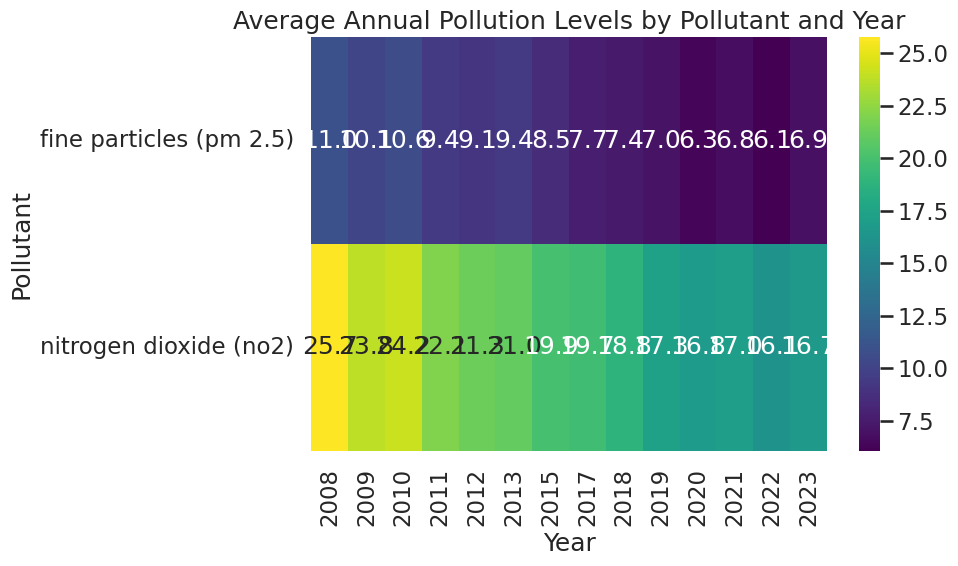

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Filter data for selected pollutants and include only 'annual average' time periods
annual_avg_data = df_raw[
    df_raw['name'].isin(['ozone (o3)', 'nitrogen dioxide (no2)', 'fine particles (pm 2.5)']) &
    df_raw['time_period'].str.contains('annual average', case=False, na=False)
].copy()

# Calculate the mean data_value for each pollutant and year
heatmap_data = annual_avg_data.groupby(['name', 'year'])['data_value'].mean().unstack()

# Display the calculated mean values
print("Average Annual Pollution Values per Pollutant and Year:")
display(heatmap_data)

# Generate the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="viridis")

plt.title('Average Annual Pollution Levels by Pollutant and Year')
plt.xlabel('Year')
plt.ylabel('Pollutant')
plt.tight_layout()
plt.show()

Note on the Heatmap Colormap:

The heatmap visualizes the average annual pollution levels.

Color Intensity: Darker colors represent higher average pollution levels for that pollutant in that specific year.

Color Scale (Viridis): This heatmap uses the 'viridis' colormap. The color bar next to the heatmap shows the range of average pollution values and their corresponding colors. Values closer to the minimum in the range are represented by one end of the colormap (e.g., yellow), and values closer to the maximum are represented by the other end (e.g., purple), with a gradient in between.

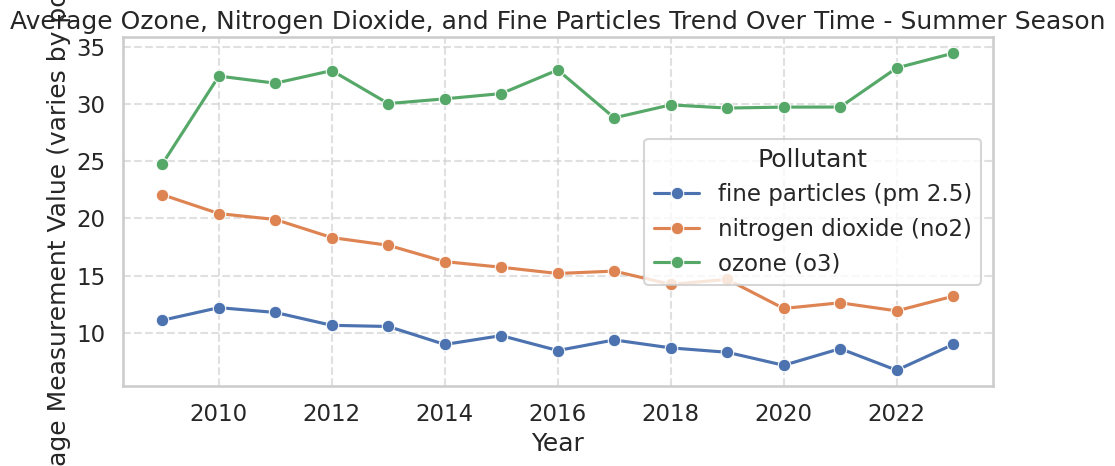

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the pollutants to plot (all three physical pollutants)
pollutants_to_plot_summer = ['ozone (o3)', 'nitrogen dioxide (no2)', 'fine particles (pm 2.5)'] # Use lowercase names

# Filter seasonal_trends for Summer data and selected pollutants
summer_seasonal_trends = seasonal_trends[
    (seasonal_trends['season'] == 'Summer') &
    (seasonal_trends['name'].isin(pollutants_to_plot_summer)) # Ensure only selected pollutants are included
].copy()

# Create a single plot for all three pollutants
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=summer_seasonal_trends,
    x='year',
    y='data_value',
    hue='name',  # Use 'name' to differentiate the lines
    marker='o' # Add markers for clarity
)

plt.title('Average Ozone, Nitrogen Dioxide, and Fine Particles Trend Over Time - Summer Season')
plt.xlabel('Year')
plt.ylabel('Average Measurement Value (varies by pollutant)')
plt.legend(title='Pollutant')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

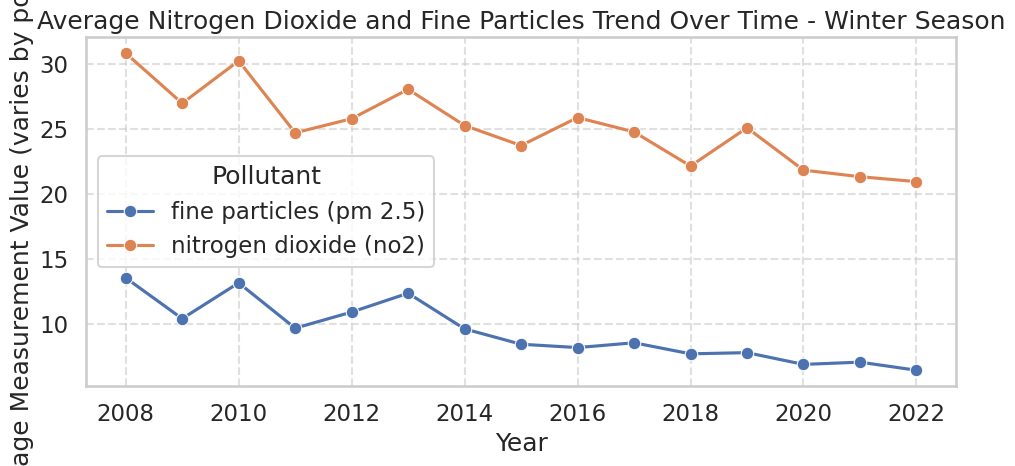

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the pollutants to plot (only those with winter data)
pollutants_to_plot_winter = ['nitrogen dioxide (no2)', 'fine particles (pm 2.5)'] # Use lowercase names

# Filter seasonal_trends for Winter data and selected pollutants
winter_seasonal_trends = seasonal_trends[
    (seasonal_trends['season'] == 'Winter') &
    (seasonal_trends['name'].isin(pollutants_to_plot_winter)) # Ensure only selected pollutants are included
].copy()


# Create a single plot for both pollutants
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=winter_seasonal_trends,
    x='year',
    y='data_value',
    hue='name',  # Use 'name' to differentiate the lines
    marker='o' # Add markers for clarity
)

plt.title('Average Nitrogen Dioxide and Fine Particles Trend Over Time - Winter Season')
plt.xlabel('Year')
plt.ylabel('Average Measurement Value (varies by pollutant)')
plt.legend(title='Pollutant')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipython-input-216921231.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=indicators_per_geo_type.index, y=indicators_per_geo_type.values, palette='viridis')


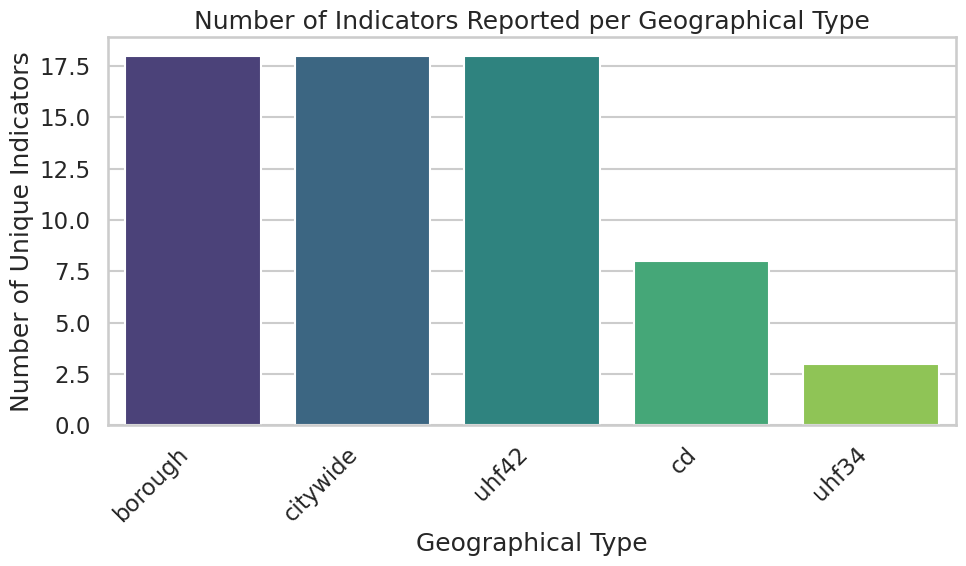

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the number of unique indicators per geo type
indicators_per_geo_type = df_raw.groupby('geo_type_name')['name'].nunique().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=indicators_per_geo_type.index, y=indicators_per_geo_type.values, palette='viridis')

plt.title('Number of Indicators Reported per Geographical Type')
plt.xlabel('Geographical Type')
plt.ylabel('Number of Unique Indicators')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

 Seasonal Coverage Consistency Check

In [ ]:
df_raw['time_period'] = df_raw['time_period'].str.lower()
df_raw['season'] = df_raw['time_period'].apply(lambda x:
    'summer' if 'summer' in str(x)
    else ('winter' if 'winter' in str(x)
    else ('annual' if 'annual' in str(x) else 'other'))
)

seasonal_trends = df_raw[df_raw['season'].isin(['summer', 'winter'])].copy()
seasonal_trends['year'] = seasonal_trends['start_date'].dt.year

In [ ]:
# Filter for Nitrogen Dioxide, Fine Particles, and Ozone seasonal trends
pollutants_to_check = ['nitrogen dioxide (no2)', 'fine particles (pm 2.5)', 'ozone (o3)']
seasonal_trends_filtered = seasonal_trends[seasonal_trends['name'].isin(pollutants_to_check)]

# Get the years with summer and winter data for each pollutant
print("Seasonal Coverage Consistency Check (Summer vs Winter Years):")
print("------------------------------------------------------------")

for pollutant in pollutants_to_check:
    pollutant_data = seasonal_trends_filtered[seasonal_trends_filtered['name'] == pollutant]

    summer_years = set(pollutant_data[pollutant_data['season'] == 'summer']['year'])
    winter_years = set(pollutant_data[pollutant_data['season'] == 'winter']['year'])

    print(f"\n--- {pollutant.title()} ---")
    print(f"Years with Summer data: {sorted(list(summer_years))}")
    print(f"Years with Winter data: {sorted(list(winter_years))}")

    if pollutant != 'ozone (o3)': # Only check summer/winter consistency for pollutants with both seasons
        if summer_years == winter_years:
            print("✅ Summer and Winter data are available for the exact same set of years.")
        else:
            print("❌ Summer and Winter data are NOT available for the exact same set of years.")
            # Optional: show missing years
            missing_in_winter = list(summer_years - winter_years)
            missing_in_summer = list(winter_years - summer_years)
            if missing_in_winter:
                print(f"  - Missing in Winter data: {sorted(missing_in_winter)}")
            if missing_in_summer:
                print(f"  - Missing in Summer data: {sorted(missing_in_summer)}")
    else:
        print("Note: Ozone data is only available for the Summer season in this dataset.")


# Find the years with both summer and winter data for BOTH Nitrogen Dioxide AND Fine Particles
pollutants_for_common_check = ['nitrogen dioxide (no2)', 'fine particles (pm 2.5)']
seasonal_trends_common_check = seasonal_trends[seasonal_trends['name'].isin(pollutants_for_common_check)]

summer_years_no2 = set(seasonal_trends_common_check[(seasonal_trends_common_check['name'] == 'nitrogen dioxide (no2)') & (seasonal_trends_common_check['season'] == 'summer')]['year'])
winter_years_no2 = set(seasonal_trends_common_check[(seasonal_trends_common_check['name'] == 'nitrogen dioxide (no2)') & (seasonal_trends_common_check['season'] == 'winter')]['year'])

summer_years_pm25 = set(seasonal_trends_common_check[(seasonal_trends_common_check['name'] == 'fine particles (pm 2.5)') & (seasonal_trends_common_check['season'] == 'summer')]['year'])
winter_years_pm25 = set(seasonal_trends_common_check[(seasonal_trends_common_check['name'] == 'fine particles (pm 2.5)') & (seasonal_trends_common_check['season'] == 'winter')]['year'])

common_summer_years = sorted(list(summer_years_no2.intersection(summer_years_pm25)))
common_winter_years = sorted(list(winter_years_no2.intersection(winter_years_pm25)))

print("\nYears with BOTH Summer and Winter Data for Nitrogen Dioxide AND Fine Particles:")
print("------------------------------------------------------------------------------")

print(f"Years with BOTH Summer data: {common_summer_years}")
print(f"Years with BOTH Winter data: {common_winter_years}")

# Check if the sets of common summer and winter years are the same
if set(common_summer_years) == set(common_winter_years):
    print("\n✅ The set of years with BOTH Summer data is the same as the set of years with BOTH Winter data.")
else:
    print("\n❌ The set of years with BOTH Summer data is NOT the same as the set of years with BOTH Winter data.")
    missing_in_common_winter = list(set(common_summer_years) - set(common_winter_years))
    missing_in_common_summer = list(set(common_winter_years) - set(common_summer_years))
    if missing_in_common_winter:
        print(f"  - Years with Summer data for BOTH but NOT Winter data for BOTH: {sorted(missing_in_common_winter)}")
    if missing_in_common_summer:
        print(f"  - Years with Winter data for BOTH but NOT Summer data for BOTH: {sorted(missing_in_common_summer)}")

Seasonal Coverage Consistency Check (Summer vs Winter Years):
------------------------------------------------------------

--- Nitrogen Dioxide (No2) ---
Years with Summer data: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Years with Winter data: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
❌ Summer and Winter data are NOT available for the exact same set of years.
  - Missing in Winter data: [2023]
  - Missing in Summer data: [2008]

--- Fine Particles (Pm 2.5) ---
Years with Summer data: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Years with Winter data: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
❌ Summer and Winter data are NOT available for the exact same set of years.
  - Missing in Winter data: [2023]
  - Missing in Summer data: [2008]

--- Ozone (O3) ---
Years with Summer data: [2009, 2010, 201

Note: Ozone data is only available for the Summer season.



This shows us overall:  

NO2, PM2.5, and O3 have data for summer years 2009-2023.

PM2.5 and NO2 have data for winter years 2008-2022, while O3 has no data for winter years- O3 is summer only.



This shows us about cross-pollutants seasonal overlap:

NO2 and PM2.5 have summer AND winter data for years 2008-2022, consistent between both pollutants.

TEMPORAL ALIGNMENT FOR INDICATORS

Using 'year' as 'aligned_year'.
📊 Temporal Summary by Indicator:



,name,Earliest Year,Latest Year,Data Count,Possible Gaps
0,annual vehicle miles traveled,2005,2019,321,Yes (12 gaps)
1,annual vehicle miles traveled (cars),2005,2019,321,Yes (12 gaps)
2,annual vehicle miles traveled (trucks),2005,2019,321,Yes (12 gaps)
3,asthma emergency department visits due to pm2.5,2005,2017,480,Yes (8 gaps)
4,asthma emergency departments visits due to ozone,2005,2017,480,Yes (8 gaps)
5,asthma hospitalizations due to ozone,2005,2017,480,Yes (8 gaps)
10,cardiovascular hospitalizations due to pm2.5 (...,2005,2017,240,Yes (8 gaps)
9,cardiac and respiratory deaths due to ozone,2005,2017,240,Yes (8 gaps)
14,outdoor air toxics - benzene,2005,2014,203,Yes (7 gaps)
15,outdoor air toxics - formaldehyde,2005,2014,203,Yes (7 gaps)



🔍 Indicator Categorization Results:

📌 Health Outcomes:
   • asthma emergency department visits due to pm2.5
   • asthma emergency departments visits due to ozone
   • asthma hospitalizations due to ozone
   • cardiac and respiratory deaths due to ozone
   • cardiovascular hospitalizations due to pm2.5 (age 40+)
   • deaths due to pm2.5
   • respiratory hospitalizations due to pm2.5 (age 20+)

📌 Physical Pollutants:
   • fine particles (pm 2.5)
   • nitrogen dioxide (no2)
   • ozone (o3)

📌 Traffic & Emissions:
   • annual vehicle miles traveled
   • annual vehicle miles traveled (cars)
   • annual vehicle miles traveled (trucks)
   • boiler emissions- total nox emissions
   • boiler emissions- total pm2.5 emissions
   • boiler emissions- total so2 emissions
   • outdoor air toxics - benzene
   • outdoor air toxics - formaldehyde

📊 Summary by Indicator Group:


,Indicator Group,Total Indicators,Earliest Year,Latest Year,Data Count
0,Health Outcomes,7,2005,2017,2400
1,Traffic & Emissions,8,2005,2019,1657
2,Physical Pollutants,3,2008,2023,14805



🕒 Temporal Overlap Analysis:
Health Outcomes          : 2005 - 2017 (13 years)
Traffic & Emissions      : 2005 - 2019 (15 years)
Physical Pollutants      : 2008 - 2023 (16 years)

Common overlap period: 2013 - 2014

🔍 Data Completeness by Group:

Health Outcomes:
   • Total indicators: 7
   • No gaps: 0
   • With gaps: 7
   • Indicators with gaps:
      - asthma emergency department visits due to pm2.5: Yes (8 gaps)
      - asthma emergency departments visits due to ozone: Yes (8 gaps)
      - asthma hospitalizations due to ozone: Yes (8 gaps)
      - cardiac and respiratory deaths due to ozone: Yes (8 gaps)
      - cardiovascular hospitalizations due to pm2.5 (age 40+): Yes (8 gaps)
      - deaths due to pm2.5: Yes (8 gaps)
      - respiratory hospitalizations due to pm2.5 (age 20+): Yes (8 gaps)

Physical Pollutants:
   • Total indicators: 3
   • No gaps: 3
   • With gaps: 0

Traffic & Emissions:
   • Total indicators: 8
   • No gaps: 0
   • With gaps: 8
   • Indicators with gaps:
 

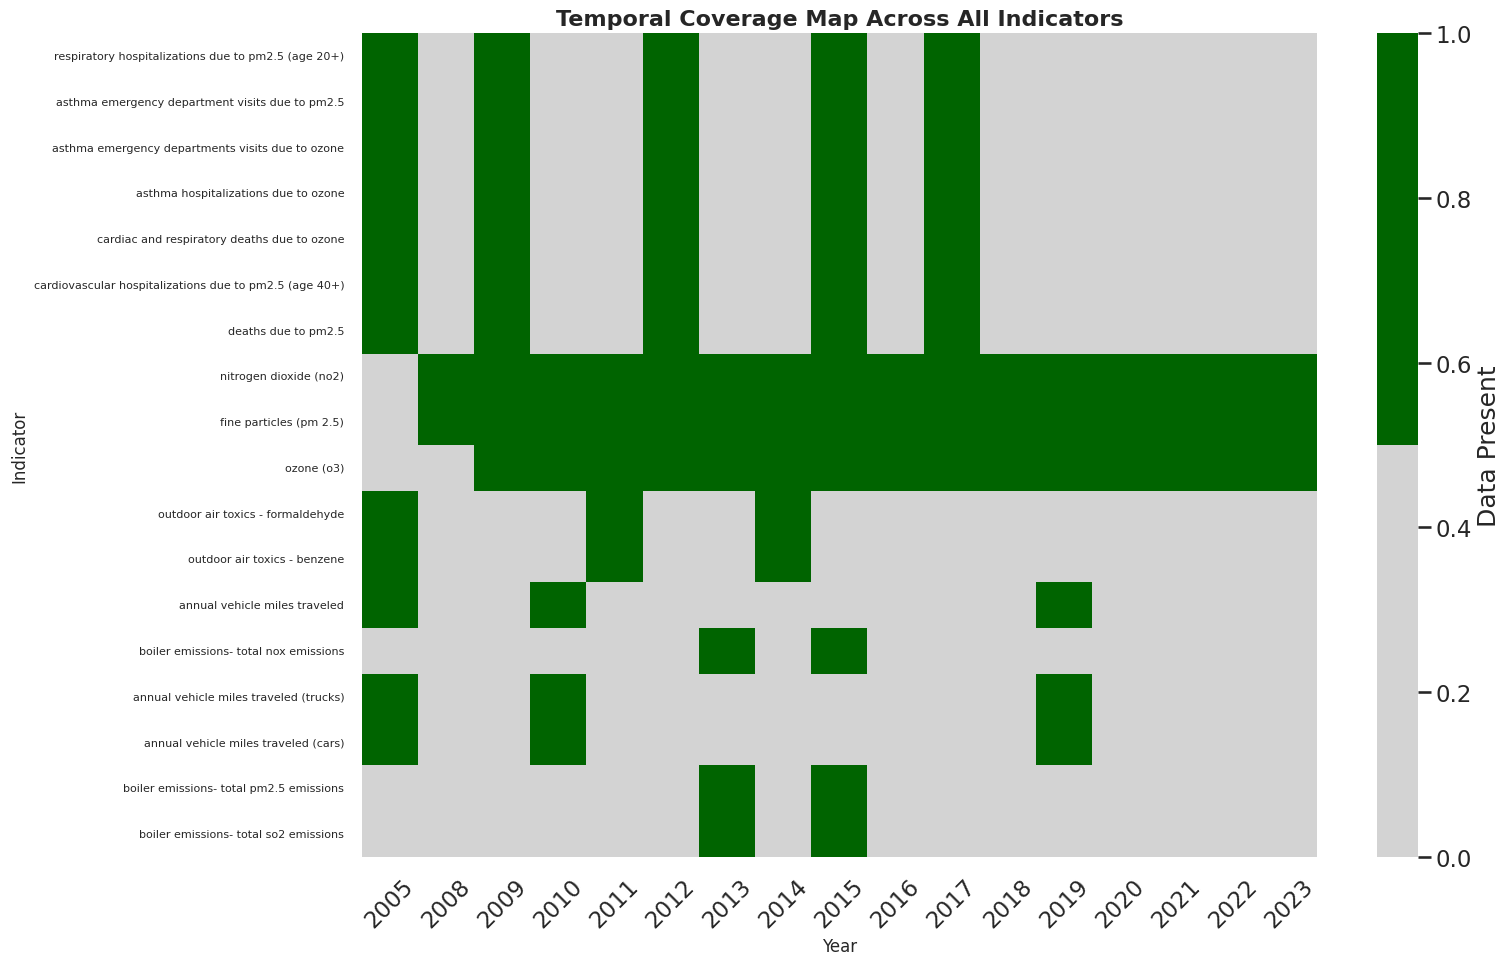

In [ ]:
# ----------------------------------------------
# TEMPORAL SUMMARY + HEATMAP (for report section to justify
#why we only used Physical Pollutants)
# ----------------------------------------------

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re # Import re if needed for other parts of the code

# Make sure we have aligned_year already (from earlier normalization)
# 'year' column is created in df_raw in cell qlQ98I2mTvon
df_raw['aligned_year'] = df_raw['year']
print("Using 'year' as 'aligned_year'.")


# 1) Create a summary table for each indicator
summary_agg = (
    df_raw.groupby('name')['aligned_year']
      .agg(['min', 'max', 'count'])
      .reset_index()
      .rename(columns={'min': 'Earliest Year', 'max': 'Latest Year', 'count': 'Data Count'})
)

# Function to check for gaps
def check_for_gaps(row, df_raw):
    name = row['name']
    earliest = row['Earliest Year']
    latest = row['Latest Year']

    if pd.isna(earliest) or pd.isna(latest):
        return 'Unknown'

    # Get all unique years present for this indicator
    years_present = set(df_raw[df_raw['name'] == name]['aligned_year'].dropna().astype(int))

    # Create a set of all expected years in the range
    expected_years = set(range(int(earliest), int(latest) + 1))

    # Check if all expected years are present
    if years_present == expected_years:
        return 'No'
    else:
        missing_years = expected_years - years_present
        return f'Yes ({len(missing_years)} gaps)'

# Apply the gap checking function
summary_agg['Possible Gaps'] = summary_agg.apply(lambda row: check_for_gaps(row, df_raw), axis=1)

# Select and reorder columns for the final summary table (removing Time Period Types)
summary_table = summary_agg[['name', 'Earliest Year', 'Latest Year', 'Data Count', 'Possible Gaps']]


# 2) Print clean summary table
print("📊 Temporal Summary by Indicator:\n")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
display(summary_table.sort_values('Earliest Year'))
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')


# 3) Improved indicator categorization
def categorize_indicator(name):
    """
    Categorizes indicator names into broader groups.
    Order matters - check most specific patterns first!
    """
    name = str(name).lower().strip()

    # Health indicators (check FIRST - most specific)
    health_keywords = [
        'asthma', 'death', 'deaths', 'hospitalization', 'hospitalizations',
        'cardiac', 'cardiovascular', 'respiratory', 'emergency department'
    ]
    if any(keyword in name for keyword in health_keywords):
        return 'Health Outcomes'

    # Traffic & Emissions (check SECOND)
    traffic_keywords = [
        'vehicle miles', 'boiler emission', 'air toxic',
        'benzene', 'formaldehyde', 'nox emission', 'so2 emission'
    ]
    if any(keyword in name for keyword in traffic_keywords):
        return 'Traffic & Emissions'

    # Physical pollutants (check LAST - use exact matches to avoid false positives)
    # Use more specific patterns to avoid matching substrings
    if name in ['nitrogen dioxide (no2)', 'fine particles (pm 2.5)', 'ozone (o3)']:
        return 'Physical Pollutants'

    # Additional pattern matching for pollutants (if naming varies slightly)
    if ('nitrogen dioxide' in name and 'no2' in name) or \
       ('fine particle' in name and 'pm' in name) or \
       ('ozone' in name and 'o3' in name):
        return 'Physical Pollutants'

    return 'Other'

summary_table['Indicator Group'] = summary_table['name'].apply(categorize_indicator)

# Print categorization results
print("\n" + "="*60)
print("🔍 Indicator Categorization Results:")
print("="*60)
for group in sorted(summary_table['Indicator Group'].unique()):
    print(f"\n📌 {group}:")
    indicators = summary_table[summary_table['Indicator Group'] == group]['name'].tolist()
    for ind in sorted(indicators):
        print(f"   • {ind}")


# 4) Group Summary with Year Ranges
group_summary = (
    summary_table.groupby('Indicator Group')
    .agg({
        'name': 'count',
        'Earliest Year': 'min',
        'Latest Year': 'max',
        'Data Count': 'sum'
    })
    .rename(columns={'name': 'Total Indicators'})
    .sort_values('Earliest Year')
    .reset_index()
)

print("\n" + "="*60)
print("📊 Summary by Indicator Group:")
print("="*60)
display(group_summary)


# 5) Temporal Overlap Analysis
print("\n" + "="*60)
print("🕒 Temporal Overlap Analysis:")
print("="*60)

# Find common year range across all groups
for group in group_summary['Indicator Group']:
    group_data = summary_table[summary_table['Indicator Group'] == group]
    # Convert to int safely, assuming NaNs are handled earlier if they could exist
    earliest = int(group_data['Earliest Year'].min())
    latest = int(group_data['Latest Year'].max())
    print(f"{group:25s}: {earliest} - {latest} ({latest - earliest + 1} years)")

# Find maximum overlap period
all_earliest = int(summary_table['Earliest Year'].max())  # Latest start
all_latest = int(summary_table['Latest Year'].min())       # Earliest end

if all_earliest <= all_latest:
    print(f"\nCommon overlap period: {all_earliest} - {all_latest}")
else:
    print(f"\nNo complete temporal overlap across all indicators!")
    print(f"   Earliest possible start: {all_earliest}")
    print(f"   Latest possible end: {all_latest}")


# 6) Detailed gap analysis by group
print("\n" + "="*60)
print("🔍 Data Completeness by Group:")
print("="*60)

for group in sorted(summary_table['Indicator Group'].unique()):
    group_data = summary_table[summary_table['Indicator Group'] == group]

    # Count indicators with gaps
    gaps = group_data['Possible Gaps'].str.startswith('Yes').sum()
    no_gaps = (group_data['Possible Gaps'] == 'No').sum()

    print(f"\n{group}:")
    print(f"   • Total indicators: {len(group_data)}")
    print(f"   • No gaps: {no_gaps}")
    print(f"   • With gaps: {gaps}")

    # Show which indicators have gaps
    if gaps > 0:
        print(f"   • Indicators with gaps:")
        for _, row in group_data[group_data['Possible Gaps'].str.startswith('Yes')].iterrows():
            print(f"      - {row['name']}: {row['Possible Gaps']}")


# 7) Visual: Coverage heatmap
coverage = (
    df_raw.pivot_table(  # Changed df to df_raw
        index='name',
        columns='aligned_year',
        values='data_value',
        aggfunc='count'
    ).notna()
)

# Add indicator group as a column for better visualization
coverage_with_group = coverage.copy()
coverage_with_group['Indicator Group'] = coverage_with_group.index.map(
    summary_table.set_index('name')['Indicator Group']
)

# Sort by group for cleaner visualization
coverage_sorted = coverage_with_group.sort_values('Indicator Group').drop('Indicator Group', axis=1)

plt.figure(figsize=(16, 10))
sns.heatmap(coverage_sorted, cmap=['lightgray', 'darkgreen'],
            cbar=True, cbar_kws={'label': 'Data Present'})
plt.title('Temporal Coverage Map Across All Indicators', fontsize=16, weight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Indicator', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()




***THIS IS AI BUT FOR REPORT REWORD TO JUSTIFY AGAIN WHY PHYSICAL POLLUTANTS***

💡 MODELING RECOMMENDATIONS:
================================================================================

1️⃣ RECOMMENDED: Physical Pollutants-Only Analysis
   • Indicators: 3
   • Year range: 2008 - 2023
   • Total records: 14,805
   • Most complete temporal coverage
   • Suitable for K-means clustering + classification

2️⃣ OPTIONAL: Health Impact Analysis
   • Overlap period: 2008 - 2017
   • Health records: 2,400
   • Requires temporal aggregation (3-year rolling)
   • Good for regression analysis (pollution → health)

3️⃣ NOT RECOMMENDED: Traffic/Emissions Features
   • Indicators: 8
   • Sparse temporal coverage (only 15 unique years)
   • Cannot be used as features for continuous modeling
   • Can be used for exploratory correlation analysis only




### Missing Data Heatmap: Indicator vs. Year

This heatmap visualizes the presence (or absence) of data for each indicator across all available years.

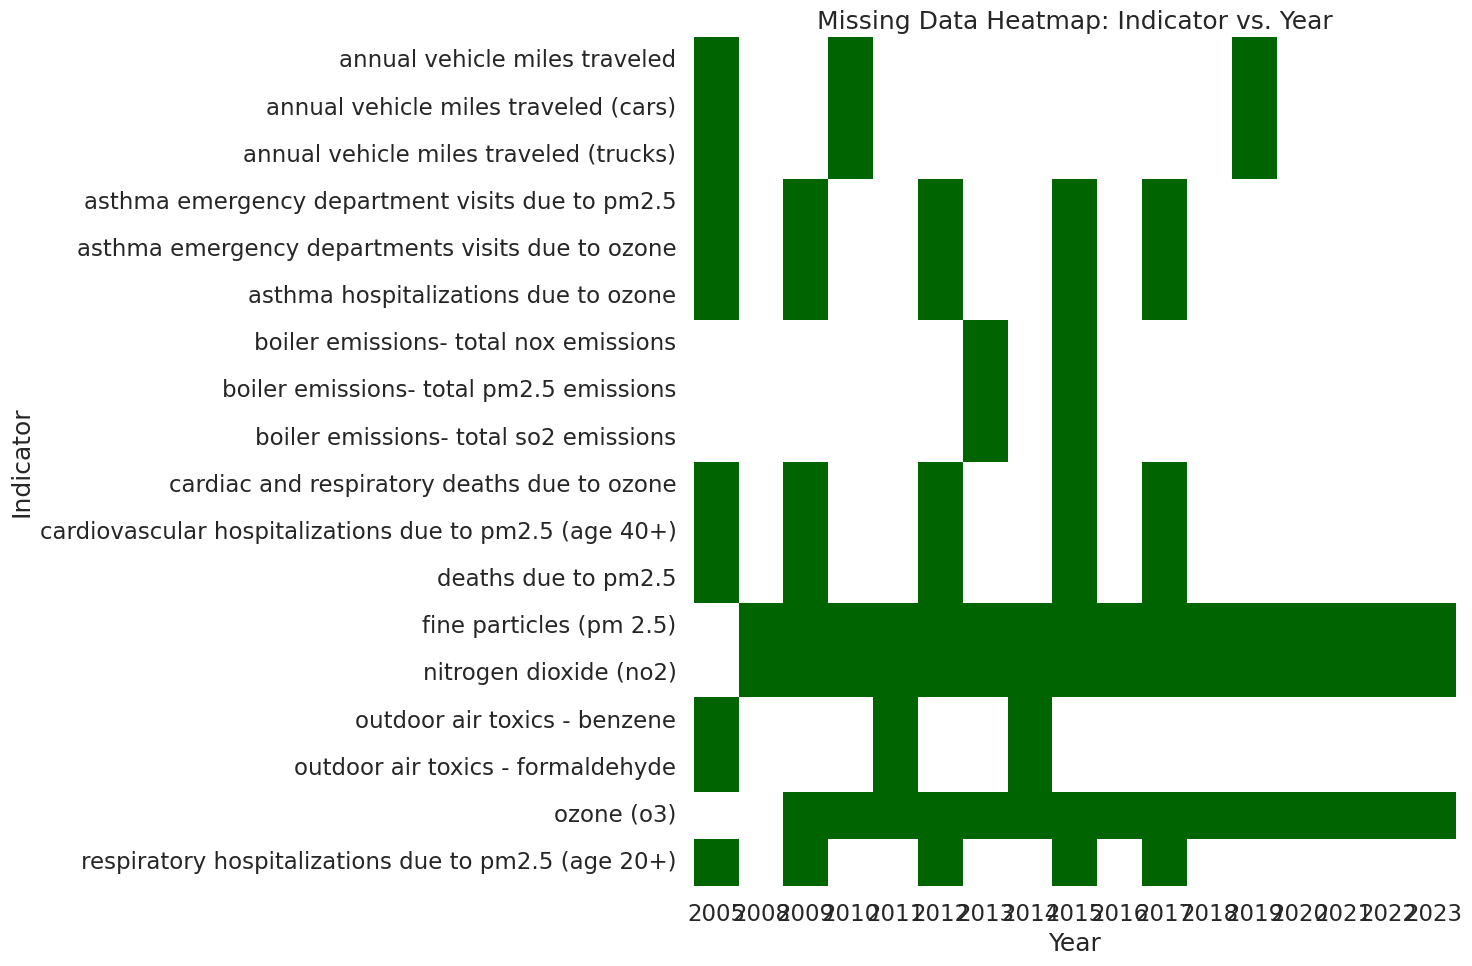

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'year' column exists (derived from start_date in earlier cleaning)
if 'year' not in df_raw.columns:
    df_raw['start_date'] = pd.to_datetime(df_raw['start_date'], errors='coerce')
    df_raw['year'] = df_raw['start_date'].dt.year

# Create a pivot table showing data presence (True) or absence (False) for each indicator and year
# Use 'count' and then check if the count is > 0 (meaning data is present)
missing_data_year = df_raw.pivot_table(
    index='name',
    columns='year',
    values='data_value',
    aggfunc='count'
).notna() # Check for non-null counts, indicating data presence

# Replace NaN with False for years where an indicator has no data at all
missing_data_year = missing_data_year.fillna(False)

# Plot the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(missing_data_year, cmap=['white', 'darkgreen'], cbar=False) # White for missing, Green for present

plt.title('Missing Data Heatmap: Indicator vs. Year')
plt.xlabel('Year')
plt.ylabel('Indicator')
plt.tight_layout()
plt.show()

### Missing Data Heatmap: Indicator vs. Season

This heatmap visualizes the presence (or absence) of data for each indicator across different seasons.

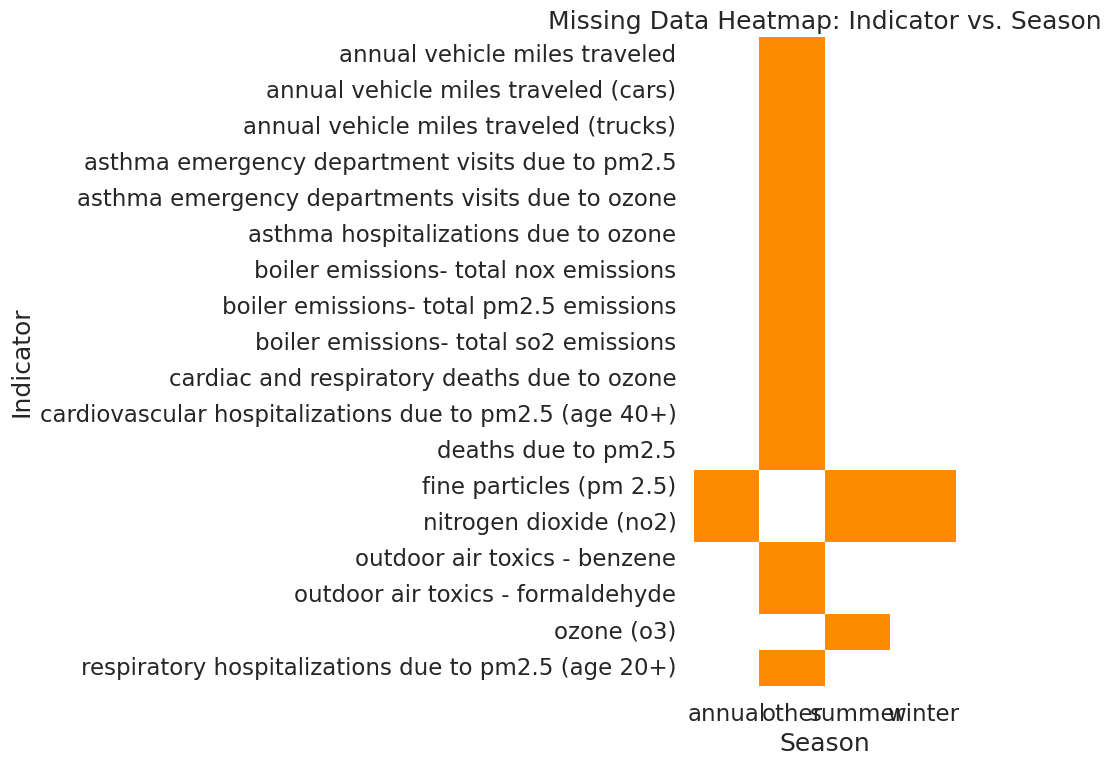

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'season' column exists (derived from time_period in earlier cleaning)
# It's already created and populated in df_raw in cell mlFeGB33WpGN
if 'season' not in df_raw.columns:
    def get_season(time_period):
        if isinstance(time_period, str):
            period_lower = time_period.lower()
            if 'winter' in period_lower: return 'Winter'
            elif 'spring' in period_lower: return 'Spring'
            elif 'summer' in period_lower: return 'Summer'
            elif 'fall' in period_lower or 'autumn' in period_lower: return 'Fall'
            elif 'annual' in period_lower: return 'Annual'
        return 'Unknown'
    df_raw['season'] = df_raw['time_period'].apply(get_season)


# Create a pivot table showing data presence for each indicator and season
missing_data_season = df_raw.pivot_table(
    index='name',
    columns='season',
    values='data_value',
    aggfunc='count'
).notna()

# Replace NaN with False for seasons where an indicator has no data at all
missing_data_season = missing_data_season.fillna(False)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(missing_data_season, cmap=['white', 'darkorange'], cbar=False) # White for missing, Orange for present

plt.title('Missing Data Heatmap: Indicator vs. Season')
plt.xlabel('Season')
plt.ylabel('Indicator')
plt.tight_layout()
plt.show()

### Missing Data Heatmap: Indicator vs. Geographic Type

This heatmap visualizes the presence (or absence) of data for each indicator across different geographic levels (geo_type_name).

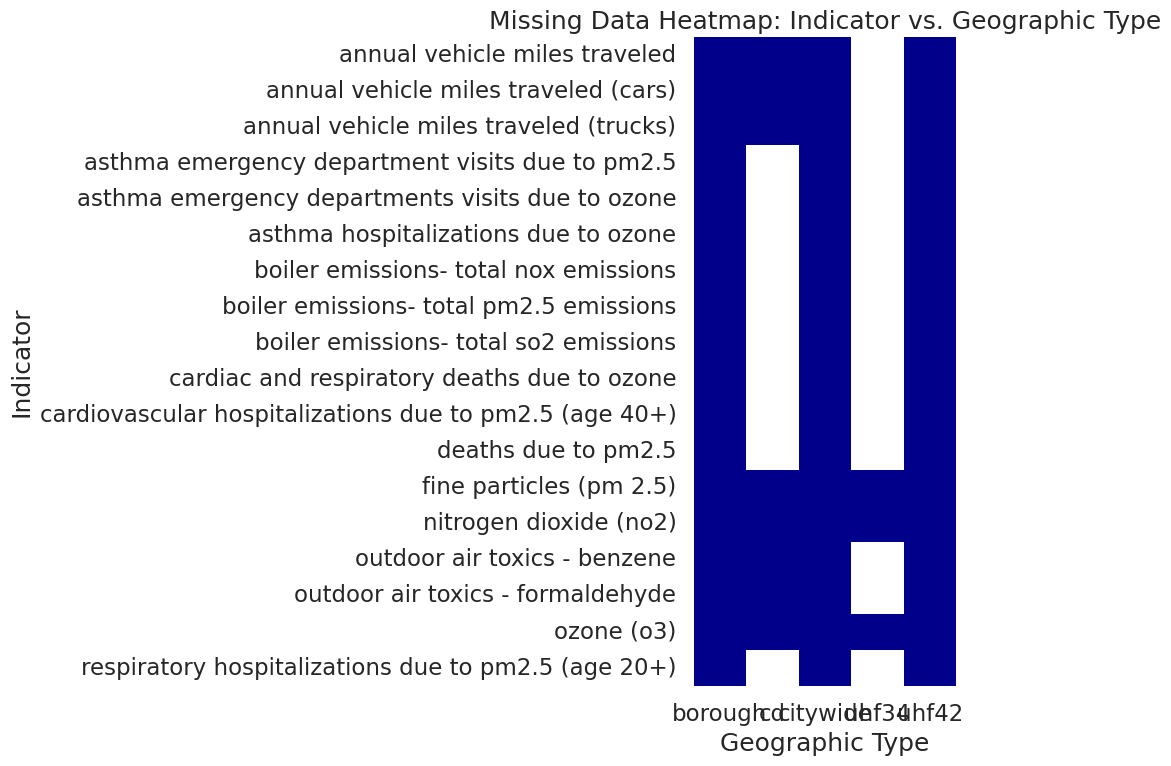

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pivot table showing data presence for each indicator and geographic type
missing_data_geo_type = df_raw.pivot_table(
    index='name',
    columns='geo_type_name',
    values='data_value',
    aggfunc='count'
).notna()

# Replace NaN with False for geo types where an indicator has no data at all
missing_data_geo_type = missing_data_geo_type.fillna(False)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(missing_data_geo_type, cmap=['white', 'darkblue'], cbar=False) # White for missing, Blue for present

plt.title('Missing Data Heatmap: Indicator vs. Geographic Type')
plt.xlabel('Geographic Type')
plt.ylabel('Indicator')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plot_labels = []
plot_values = []

for col, mis_rate_series in mis_by_geo.items():
    # Iterate through the 0 and 1 values (or other unique values if not binary)
    for value, rate in mis_rate_series.items():
        label = f"{col.replace('geo_', '')}_{value}" # e.g., 'borough_1', 'borough_0'
        plot_labels.append(label)
        plot_values.append(rate)

if plot_labels:
    plt.bar(plot_labels, plot_values, color='coral')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Misclassification Rate")
    plt.title("Naive Bayes Misclassification Rate by Geo Type Categories")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassification rates by geo type categories to display.")

No misclassification rates by geo type categories to display.


<Figure size 1200x600 with 0 Axes>

 Geographical Data Consistency and Distribution

/tmp/ipython-input-216921231.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=indicators_per_geo_type.index, y=indicators_per_geo_type.values, palette='viridis')


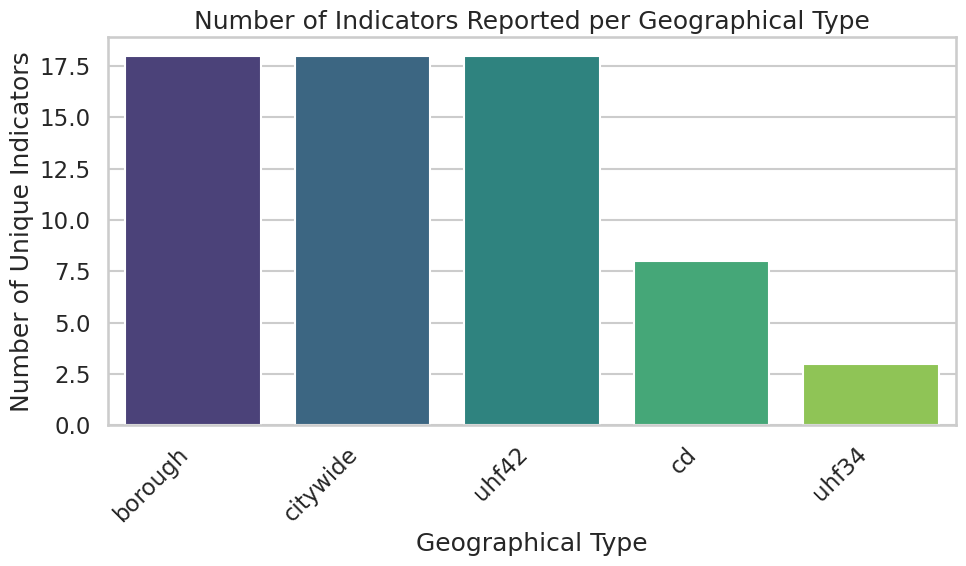

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the number of unique indicators per geo type
indicators_per_geo_type = df_raw.groupby('geo_type_name')['name'].nunique().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=indicators_per_geo_type.index, y=indicators_per_geo_type.values, palette='viridis')

plt.title('Number of Indicators Reported per Geographical Type')
plt.xlabel('Geographical Type')
plt.ylabel('Number of Unique Indicators')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

The bar chart illustrates the number of indicators associated with each geographical type. For example, borough-level data contains the highest number of reported indicators, while UHF34 (hospital-region zones) has the least coverage. This highlights how certain data, such as pollutants and health outcomes, are collected at different spatial resolutions. From this visualization, it is evident that indicators are most comprehensively available at the borough, citywide, and UHF42 levels, while CD and UHF34 contain fewer indicators.

Pollutant and associated geographical types:

In [ ]:
import pandas as pd

# Get unique combinations of indicator name and geographical type
indicator_geo_type_mapping = df_raw[['name', 'geo_type_name']].drop_duplicates().sort_values(by=['name', 'geo_type_name']).reset_index(drop=True)

print("Each indicator and its associated geographical type (all unique combinations):")
display(indicator_geo_type_mapping)

Each indicator and its associated geographical type (all unique combinations):


,name,geo_type_name
0,annual vehicle miles traveled,borough
1,annual vehicle miles traveled,cd
2,annual vehicle miles traveled,citywide
3,annual vehicle miles traveled,uhf42
4,annual vehicle miles traveled (cars),borough
...,...,...
60,ozone (o3),uhf34
61,ozone (o3),uhf42
62,respiratory hospitalizations due to pm2.5 (age...,borough
63,respiratory hospitalizations due to pm2.5 (age...,citywide


The accompanying table lists each indicator alongside the geographical levels it appears in. This helps determine which geography offers the widest data coverage, ensuring consistency across indicators used for analysis. Maintaining consistency is crucial — comparing data measured at different spatial levels (e.g., borough vs. neighborhood) would be misleading, similar to comparing oranges and watermelons. Therefore, this step ensures that all indicators used later in the analysis are measured at the same geographic level before any modeling or comparisons are performed.



Summary by Indicator Group:

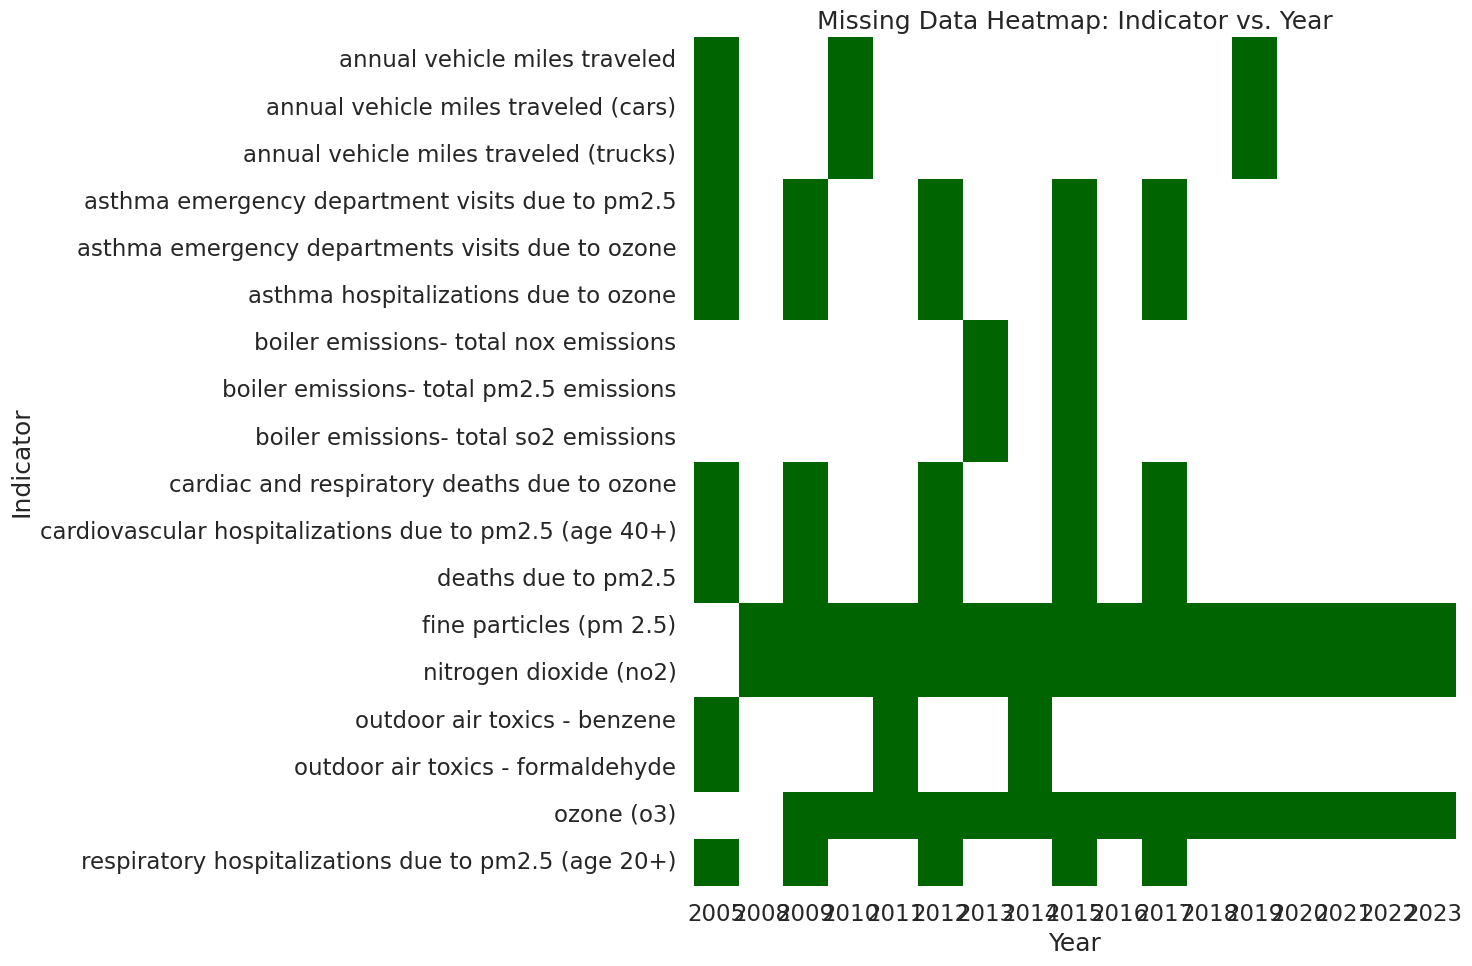

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'year' column exists (derived from start_date in earlier cleaning)
if 'year' not in df_raw.columns:
    df_raw['start_date'] = pd.to_datetime(df_raw['start_date'], errors='coerce')
    df_raw['year'] = df_raw['start_date'].dt.year

# Create a pivot table showing data presence (True) or absence (False) for each indicator and year
# Use 'count' and then check if the count is > 0 (meaning data is present)
missing_data_year = df_raw.pivot_table(
    index='name',
    columns='year',
    values='data_value',
    aggfunc='count'
).notna() # Check for non-null counts, indicating data presence

# Replace NaN with False for years where an indicator has no data at all
missing_data_year = missing_data_year.fillna(False)

# Plot the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(missing_data_year, cmap=['white', 'darkgreen'], cbar=False) # White for missing, Green for present

plt.title('Missing Data Heatmap: Indicator vs. Year')
plt.xlabel('Year')
plt.ylabel('Indicator')
plt.tight_layout()
plt.show()

Filter Data for CD- Level Clustering and Classification


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


pollutants = ['nitrogen dioxide (no2)', 'fine particles (pm 2.5)', 'ozone (o3)']

df_cd_filtered = df_raw[
    (df_raw['name'].isin(pollutants)) &
    (df_raw['season'] == 'summer') &
    (df_raw['geo_type_name'] == 'cd')  # ← CD level instead of borough
].copy()

print(f"Total CD records: {len(df_cd_filtered):,}")
print(f"Unique years: {df_cd_filtered['year'].nunique()}")
print(f"Unique CDs: {df_cd_filtered['geo_place_name'].nunique()}")
print(f"Pollutants: {sorted(df_cd_filtered['name'].unique())}")

if len(df_cd_filtered) == 0:
    print("\n❌ ERROR: No CD data found!")
    print("Check if geo_type_name has 'cd' values")
    raise ValueError("No CD data")


Total CD records: 2,655
Unique years: 15
Unique CDs: 59
Pollutants: ['fine particles (pm 2.5)', 'nitrogen dioxide (no2)', 'ozone (o3)']


In [ ]:
pollutants = ['nitrogen dioxide (no2)', 'fine particles (pm 2.5)', 'ozone (o3)']

df_filtered = df_raw[
    (df_raw['name'].isin(pollutants)) &
    (df_raw['season'] == 'summer') &
    (df_raw['geo_type_name'] == 'cd')
].copy()

df_wide = df_filtered.pivot_table(
    index=['geo_place_name', 'year', 'geo_join_id'], # ← Included geo_join_id here
    columns='name',
    values='data_value',
    aggfunc='mean'
).reset_index()

df_wide.columns.name = None
df_wide = df_wide.rename(columns={
    'nitrogen dioxide (no2)': 'NO2',
    'fine particles (pm 2.5)': 'PM25',
    'ozone (o3)': 'O3'
})

print(f"✅ Data shape: {df_wide.shape}")
print(f"   Rows (observations): {len(df_wide)}")
print(f"   Columns: {df_wide.columns.tolist()}")

##Now adding the parent_borough mapping

def map_borough(gid):
    if 101 <= gid <= 112:
        return "manhattan"
    elif 201 <= gid <= 212:
        return "bronx"
    elif 301 <= gid <= 318:
        return "brooklyn"
    elif 401 <= gid <= 414:
        return "queens"
    elif 501 <= gid <= 503:
        return "staten island"
    else:
        return "unknown"

df_wide['parent_borough'] = df_wide['geo_join_id'].apply(map_borough)

# Check unknowns
unknowns = df_wide[df_wide['parent_borough'] == 'unknown']
if len(unknowns) > 0:
    print("\n☢️ WARNING: Some geo_join_id values outside known CD ranges:")
    print(unknowns[['geo_place_name', 'geo_join_id']].drop_duplicates())
else:
    print("\n✅ All CDs successfully mapped to boroughs via geo_join_id ranges!")

print("\nBorough counts:")
print(df_wide['parent_borough'].value_counts())

# Drop unknown parent boroughs if any, to keep consistency with the classification experiment
df_wide = df_wide[df_wide['parent_borough'] != 'unknown'].copy()

print(f"\n✅ Parent borough mapping applied. New data shape: {df_wide.shape}")

✅ Data shape: (885, 6)
   Rows (observations): 885
   Columns: ['geo_place_name', 'year', 'geo_join_id', 'PM25', 'NO2', 'O3']

✅ All CDs successfully mapped to boroughs via geo_join_id ranges!

Borough counts:
parent_borough
brooklyn         270
queens           210
bronx            180
manhattan        180
staten island     45
Name: count, dtype: int64

✅ Parent borough mapping applied. New data shape: (885, 7)


Checking filtered data for validation

Check Sample Size

In [ ]:

n_observations = len(df_wide)
n_cds = df_wide['geo_place_name'].nunique()
n_parent_boroughs = df_wide['parent_borough'].nunique()

# Features for classification: geo_place_name (one-hot) + parent_borough (one-hot) + year (numeric)
# drop_first=True for one-hot encoding
n_features_for_classification = (n_cds - 1) + (n_parent_boroughs - 1) + 1

print(f"\n📊 Sample Size Analysis:")
print(f"   Total observations: {n_observations}")
print(f"   Unique CDs: {n_cds}")
print(f"   Unique Parent Boroughs: {n_parent_boroughs}")
print(f"   Features for classification (after one-hot encoding): {n_features_for_classification}")
print(f"   Observations-to-features ratio: {n_observations / n_features_for_classification:.1f}:1")

# Rule of thumb checks
train_size = int(n_observations * 0.8)
obs_per_feature = train_size / n_features_for_classification

print(f"\n🎯 After 80/20 split:")
print(f"   Training samples: {train_size}")
print(f"   Test samples: {n_observations - train_size}")
print(f"   Training samples per feature: {obs_per_feature:.1f}")

# Verdict
print(f"\n{'='*70}")
if obs_per_feature >= 10:
    print(f"✅ EXCELLENT: {obs_per_feature:.1f} samples/feature (need ≥10)")
    print(f"   Your dataset is WELL-SIZED for machine learning")
    sample_verdict = "PASS"
elif obs_per_feature >= 5:
    print(f"⚠️  ACCEPTABLE: {obs_per_feature:.1f} samples/feature (need ≥10)")
    print(f"   Adequate but not ideal - watch for overfitting")
    sample_verdict = "MARGINAL"
else:
    print(f"❌ TOO SMALL: {obs_per_feature:.1f} samples/feature (need ≥10)")
    print(f"   Risk of severe overfitting - need more data")
    sample_verdict = "FAIL"



📊 Sample Size Analysis:
   Total observations: 885
   Unique CDs: 59
   Unique Parent Boroughs: 5
   Features for classification (after one-hot encoding): 63
   Observations-to-features ratio: 14.0:1

🎯 After 80/20 split:
   Training samples: 708
   Test samples: 177
   Training samples per feature: 11.2

✅ EXCELLENT: 11.2 samples/feature (need ≥10)
   Your dataset is WELL-SIZED for machine learning


Checking for Missing Values

In [ ]:
missing_before = df_wide[['NO2', 'PM25', 'O3']].isnull().sum()
print(f"\nMissing values per pollutant:")
print(missing_before)

total_missing_pct = missing_before.sum() / (len(df_wide) * 3) * 100
print(f"\nTotal missing: {missing_before.sum()} / {len(df_wide) * 3} ({total_missing_pct:.1f}%)")

# Drop missing and show impact
df_clean = df_wide.dropna(subset=['NO2', 'PM25', 'O3']).copy()
rows_dropped = len(df_wide) - len(df_clean)
pct_dropped = rows_dropped / len(df_wide) * 100

print(f"\nAfter dropping missing values:")
print(f"   Rows dropped: {rows_dropped} ({pct_dropped:.1f}%)")
print(f"   Rows remaining: {len(df_clean)}")

print(f"\n{'='*70}")
if pct_dropped < 5:
    print(f"✅ EXCELLENT: Only {pct_dropped:.1f}% data loss")
    missing_verdict = "PASS"
elif pct_dropped < 15:
    print(f"⚠️  ACCEPTABLE: {pct_dropped:.1f}% data loss (not ideal)")
    missing_verdict = "MARGINAL"
else:
    print(f"❌ CONCERNING: {pct_dropped:.1f}% data loss - investigate why")
    missing_verdict = "FAIL"
print(f"{'='*70}")

# Update working dataframe
df_wide = df_clean



Missing values per pollutant:
NO2     0
PM25    0
O3      0
dtype: int64

Total missing: 0 / 2655 (0.0%)

After dropping missing values:
   Rows dropped: 0 (0.0%)
   Rows remaining: 885

✅ EXCELLENT: Only 0.0% data loss


In [ ]:
Checking for Outliers

In [ ]:
for pollutant in ['NO2', 'PM25', 'O3']:
    Q1 = df_wide[pollutant].quantile(0.25)
    Q3 = df_wide[pollutant].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_wide[(df_wide[pollutant] < lower_bound) | (df_wide[pollutant] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = n_outliers / len(df_wide) * 100

    print(f"\n{pollutant}:")
    print(f"   Range: {df_wide[pollutant].min():.2f} - {df_wide[pollutant].max():.2f}")
    print(f"   IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"   Outliers: {n_outliers} ({pct_outliers:.1f}%)")

    if n_outliers > 0:
        print(f"   Extreme values: {outliers[pollutant].sort_values(ascending=False).head(3).tolist()}")


print(f"✅ Outliers are EXPECTED in pollution data (hotspots, events)")
print(f"   Keep them - they represent real variation")




NO2:
   Range: 4.85 - 45.00
   IQR bounds: [3.85, 27.80]
   Outliers: 35 (4.0%)
   Extreme values: [45.0, 41.53, 41.44]

PM25:
   Range: 5.54 - 16.12
   IQR bounds: [4.53, 14.36]
   Outliers: 6 (0.7%)
   Extreme values: [16.12, 16.03, 15.55]

O3:
   Range: 14.38 - 43.40
   IQR bounds: [23.26, 38.72]
   Outliers: 32 (3.6%)
   Extreme values: [43.40081576, 41.2931847, 40.4]
✅ Outliers are EXPECTED in pollution data (hotspots, events)
   Keep them - they represent real variation


Checking the Feature Distribution and Correlation

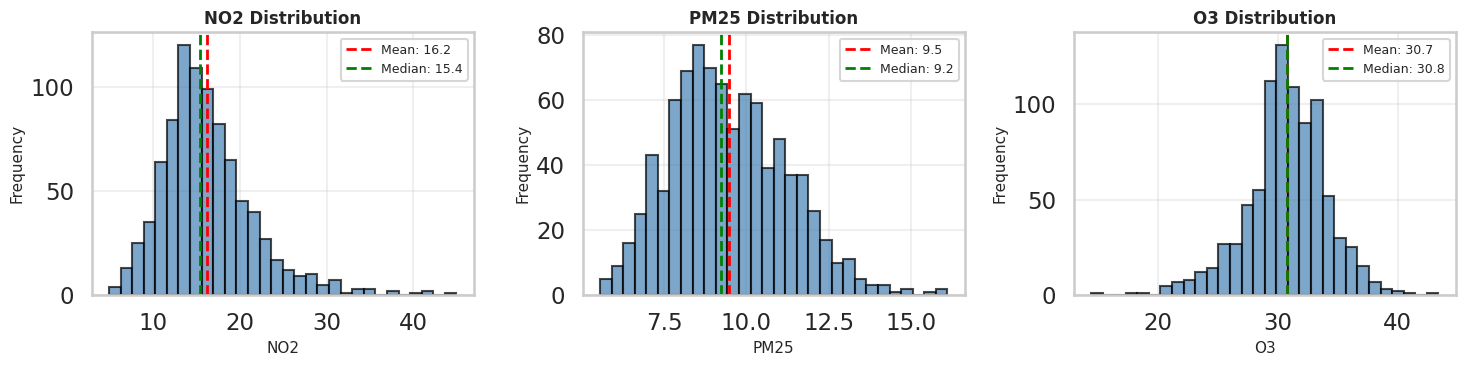

✅ Saved: data_quality_distributions.png

Normality Tests (Shapiro-Wilk):
   NO2: p=0.0000 → Non-normal
   PM25: p=0.0000 → Non-normal
   O3: p=0.0000 → Non-normal

ℹ️  Note: Non-normality is OK for K-means and Random Forest
   Only matters for Naive Bayes (assumes normality)

CHECK 5: FEATURE CORRELATIONS

Correlation Matrix:
        NO2   PM25     O3
NO2   1.000  0.823 -0.661
PM25  0.823  1.000 -0.367
O3   -0.661 -0.367  1.000


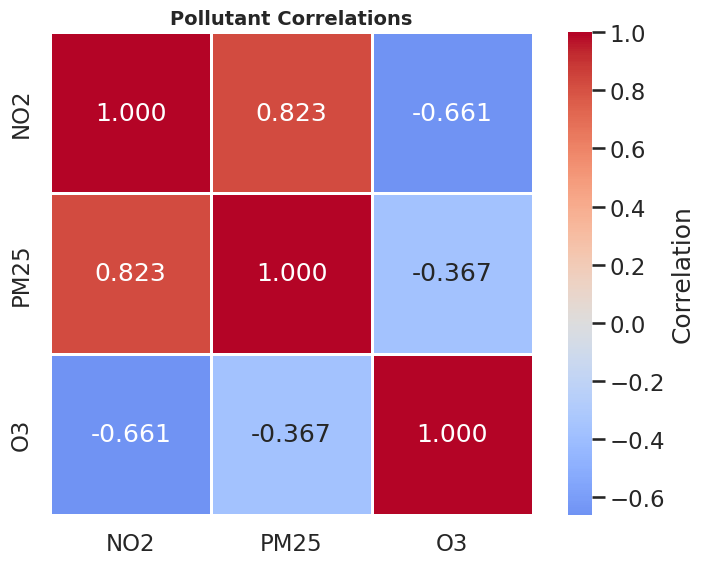

✅ Saved: data_quality_correlations.png

⚠️  HIGH CORRELATIONS DETECTED:
   NO2 ↔ PM25: 0.823
   This may cause multicollinearity (but OK for tree-based models)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # Import the stats module for Shapiro-Wilk test

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (ax, pollutant) in enumerate(zip(axes, ['NO2', 'PM25', 'O3'])):
    # Histogram with KDE
    ax.hist(df_wide[pollutant], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_xlabel(pollutant, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{pollutant} Distribution', fontsize=12, weight='bold')
    ax.grid(True, alpha=0.3)

    # Add mean/median lines
    mean_val = df_wide[pollutant].mean()
    median_val = df_wide[pollutant].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('data_quality_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: data_quality_distributions.png")

# Normality test
print(f"\nNormality Tests (Shapiro-Wilk):")
for pollutant in ['NO2', 'PM25', 'O3']:
    stat, p_value = stats.shapiro(df_wide[pollutant].sample(min(5000, len(df_wide))))
    is_normal = "Normal" if p_value > 0.05 else "Non-normal"
    print(f"   {pollutant}: p={p_value:.4f} → {is_normal}")

print(f"\n{'='*70}")
print(f"ℹ️  Note: Non-normality is OK for K-means and Random Forest")
print(f"   Only matters for Naive Bayes (assumes normality)")
print(f"{'='*70}")

# ============================================================
# CHECK 5: FEATURE CORRELATIONS
# ============================================================

print("\n" + "="*70)
print("CHECK 5: FEATURE CORRELATIONS")
print("="*70)

corr_matrix = df_wide[['NO2', 'PM25', 'O3']].corr()

print(f"\nCorrelation Matrix:")
print(corr_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={'label': 'Correlation'})
plt.title('Pollutant Correlations', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('data_quality_correlations.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: data_quality_correlations.png")

# Check for high correlations
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = abs(corr_matrix.iloc[i, j])
        if corr_val > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

print(f"\n{'='*70}")
if len(high_corr) > 0:
    print(f"⚠️  HIGH CORRELATIONS DETECTED:")
    for feat1, feat2, corr_val in high_corr:
        print(f"   {feat1} ↔ {feat2}: {corr_val:.3f}")
    print(f"   This may cause multicollinearity (but OK for tree-based models)")
    corr_verdict = "MARGINAL"
else:
    print(f"✅ GOOD: No excessive correlations (all < 0.8)")
    corr_verdict = "PASS"
print(f"{'='*70}")

K-MEANS CLUSTERING

In [ ]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cd_wide[['NO2', 'PM25', 'O3']])

# K-means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cd_wide['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Cluster distribution:")
print(df_cd_wide['cluster'].value_counts().sort_index())

cluster_means = df_cd_wide.groupby('cluster')[['NO2', 'PM25', 'O3']].mean()
print(f"\nCluster means:")
print(cluster_means.round(2))


Cluster distribution:
cluster
0    109
1    420
2    356
Name: count, dtype: int64

Cluster means:
           NO2   PM25     O3
cluster                     
0        26.39  11.92  24.98
1        12.27   8.04  32.16
2        17.78  10.38  30.83


POST CLUSTERING QUALITY CHECKS


In [ ]:

from sklearn.metrics import silhouette_score, calinski_harabasz_score

print("\n" + "="*70)
print("STEP 4: CLUSTER QUALITY CHECKS")
print("="*70)

X_scaled = scaler.fit_transform(df_cd_wide[['NO2', 'PM25', 'O3']])
labels = df_cd_wide['cluster']

sil = silhouette_score(X_scaled, labels)
cal = calinski_harabasz_score(X_scaled, labels)

print(f"Silhouette Score: {sil:.3f}")
print(f"Calinski-Harabasz Score: {cal:.1f}")

# Cluster balance
counts = df_cd_wide['cluster'].value_counts().sort_index()
pcts = (counts / len(df_cd_wide) * 100).round(1)

print("\nCluster Distribution:")
for c, ct in counts.items():
    print(f"  Cluster {c}: {ct} observations ({pcts[c]}%)")

imbalance_ratio = pcts.max() / pcts.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")



STEP 4: CLUSTER QUALITY CHECKS
Silhouette Score: 0.343
Calinski-Harabasz Score: 687.0

Cluster Distribution:
  Cluster 0: 109 observations (12.3%)
  Cluster 1: 420 observations (47.5%)
  Cluster 2: 356 observations (40.2%)

Imbalance Ratio: 3.86:1


ELBOW-METHOD FOR K-MEANS

Running elbow method...


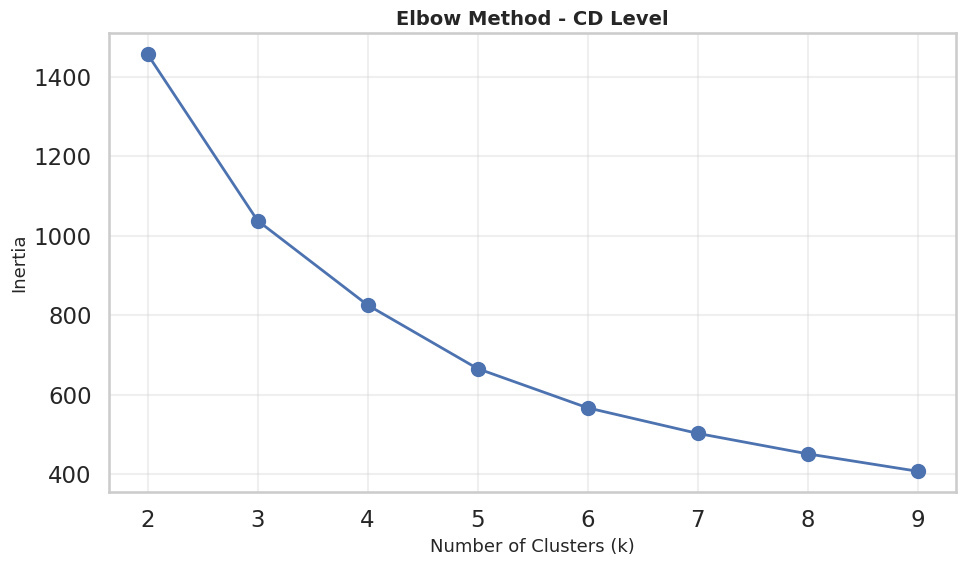

✅ Saved: cd_elbow_plot.png

✅ Clustering complete (k=3)

Cluster distribution:
cluster
0    109
1    420
2    356
Name: count, dtype: int64

Cluster means:
           NO2   PM25     O3
cluster                     
0        26.39  11.92  24.98
1        12.27   8.04  32.16
2        17.78  10.38  30.83


In [ ]:
print("Running elbow method...")
inertias = []
K_range = range(2, 10)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'o-', linewidth=2, markersize=10)
plt.xlabel('Number of Clusters (k)', fontsize=13)
plt.ylabel('Inertia', fontsize=13)
plt.title('Elbow Method - CD Level', fontsize=14, weight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cd_elbow_plot.png', dpi=300)
plt.show()
print("✅ Saved: cd_elbow_plot.png")

# Final clustering with k=3
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_wide['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"\n✅ Clustering complete (k={optimal_k})")
print(f"\nCluster distribution:")
print(df_wide['cluster'].value_counts().sort_index())

cluster_means = df_wide.groupby('cluster')[['NO2', 'PM25', 'O3']].mean()
print(f"\nCluster means:")
print(cluster_means.round(2))


CLASSIFICATION with and without Parent Borough Feature

In [ ]:
print("\n" + "="*70)
print("STEP 5: EXPERIMENT - HIERARCHICAL FEATURES")
print("="*70)

# Prepare target
y = df_wide['cluster']

# ============== MODEL 1: Without parent_borough ===============
print("\n1′️ MODEL WITHOUT parent_borough:")

X1 = df_wide[['geo_place_name', 'year']].copy()
X1_encoded = pd.get_dummies(X1, columns=['geo_place_name'], drop_first=True)

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1_encoded, y, test_size=0.2, random_state=42, stratify=y
)

rf1 = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15)
rf1.fit(X1_train, y1_train)

acc1_train = rf1.score(X1_train, y1_train)
acc1_test = rf1.score(X1_test, y1_test)
cv1 = cross_val_score(rf1, X1_train, y1_train, cv=5).mean()

print(f"   Features: {X1_encoded.shape[1]} (CD name + year)")
print(f"   Train Accuracy: {acc1_train:.3f}")
print(f"   Test Accuracy:  {acc1_test:.3f}")
print(f"   CV Accuracy:    {cv1:.3f}")


# ============== MODEL 2: With parent_borough ===============
print("\n2′️ MODEL WITH parent_borough:")

X2 = df_wide[['geo_place_name', 'parent_borough', 'year']].copy()
X2_encoded = pd.get_dummies(X2, columns=['geo_place_name', 'parent_borough'], drop_first=True)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_encoded, y, test_size=0.2, random_state=42, stratify=y
)

rf2 = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15)
rf2.fit(X2_train, y2_train)

acc2_train = rf2.score(X2_train, y2_train)
acc2_test = rf2.score(X2_test, y2_test)
cv2 = cross_val_score(rf2, X2_train, y2_train, cv=5).mean()

print(f"   Features: {X2_encoded.shape[1]} (CD name + parent borough + year)")
print(f"   Train Accuracy: {acc2_train:.3f}")
print(f"   Test Accuracy:  {acc2_test:.3f}")
print(f"   CV Accuracy:    {cv2:.3f}")


STEP 5: EXPERIMENT - HIERARCHICAL FEATURES

1′️ MODEL WITHOUT parent_borough:
   Features: 59 (CD name + year)
   Train Accuracy: 0.936
   Test Accuracy:  0.797
   CV Accuracy:    0.778

2′️ MODEL WITH parent_borough:
   Features: 63 (CD name + parent borough + year)
   Train Accuracy: 0.963
   Test Accuracy:  0.831
   CV Accuracy:    0.811


Comparison of both


In [ ]:
comparison = pd.DataFrame({
    'Model': ['Without parent_borough', 'With parent_borough'],
    'Features': [X1_encoded.shape[1], X2_encoded.shape[1]],
    'Train Acc': [acc1_train, acc2_train],
    'Test Acc': [acc1_test, acc2_test],
    'CV Acc': [cv1, cv2]
})

print("\n" + comparison.to_string(index=False))

improvement = acc2_test - acc1_test
print(f"\n{'='*70}")
if improvement > 0.02:  # >2% improvement
    print(f"✅ RESULT: Adding parent_borough HELPS! (+{improvement:.3f})")
    print(f"   Recommendation: KEEP parent_borough feature")
    decision = "KEEP"
elif improvement > 0:
    print(f"⚠️  RESULT: Marginal improvement (+{improvement:.3f})")
    print(f"   Recommendation: Optional - small benefit")
    decision = "OPTIONAL"
else:
    print(f"❌ RESULT: No improvement ({improvement:.3f})")
    print(f"   Recommendation: DROP parent_borough (adds complexity without benefit)")
    decision = "DROP"
print(f"{'='*70}")



                 Model  Features  Train Acc  Test Acc   CV Acc
Without parent_borough        59   0.936441  0.796610 0.778324
   With parent_borough        63   0.963277  0.830508 0.810778

✅ RESULT: Adding parent_borough HELPS! (+0.034)
   Recommendation: KEEP parent_borough feature


Feature Importance of Model 2

In [ ]:
if improvement >= 0:  # If parent_borough helped at all

    importances = pd.DataFrame({
        'Feature': X2_encoded.columns,
        'Importance': rf2.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\n️️ Top 15 Most Important Features:")
    print(importances.head(15).to_string(index=False))

    # Check parent_borough importance
    parent_features = importances[importances['Feature'].str.contains('parent_borough')]
    if len(parent_features) > 0:
        print(f"\n📍 Parent Borough Features:")
        print(parent_features.to_string(index=False))

        total_parent_importance = parent_features['Importance'].sum()
        print(f"\n   Total parent_borough importance: {total_parent_importance:.3f}")

        if total_parent_importance > 0.10:
            print(f"   → Borough-level patterns are STRONG predictors!")
        elif total_parent_importance > 0.05:
            print(f"   → Borough-level patterns have MODERATE influence")
        else:
            print(f"   → Borough-level patterns have WEAK influence")




️️ Top 15 Most Important Features:
                                            Feature  Importance
                                               year    0.579246
                           parent_borough_manhattan    0.078088
    geo_place_name_greenwich village and soho (cd2)    0.020743
                       geo_place_name_midtown (cd5)    0.020560
           geo_place_name_clinton and chelsea (cd4)    0.016746
            geo_place_name_financial district (cd1)    0.016536
geo_place_name_stuyvesant town and turtle bay (cd6)    0.016414
   geo_place_name_rockaway and broad channel (cd14)    0.015194
        geo_place_name_woodside and sunnyside (cd2)    0.013885
geo_place_name_park slope and carroll gardens (cd6)    0.013618
                              parent_borough_queens    0.012967
                       parent_borough_staten island    0.012279
   geo_place_name_tottenville and great kills (cd3)    0.011223
        geo_place_name_mott haven and melrose (cd1)    0.009502
 geo

Visualization

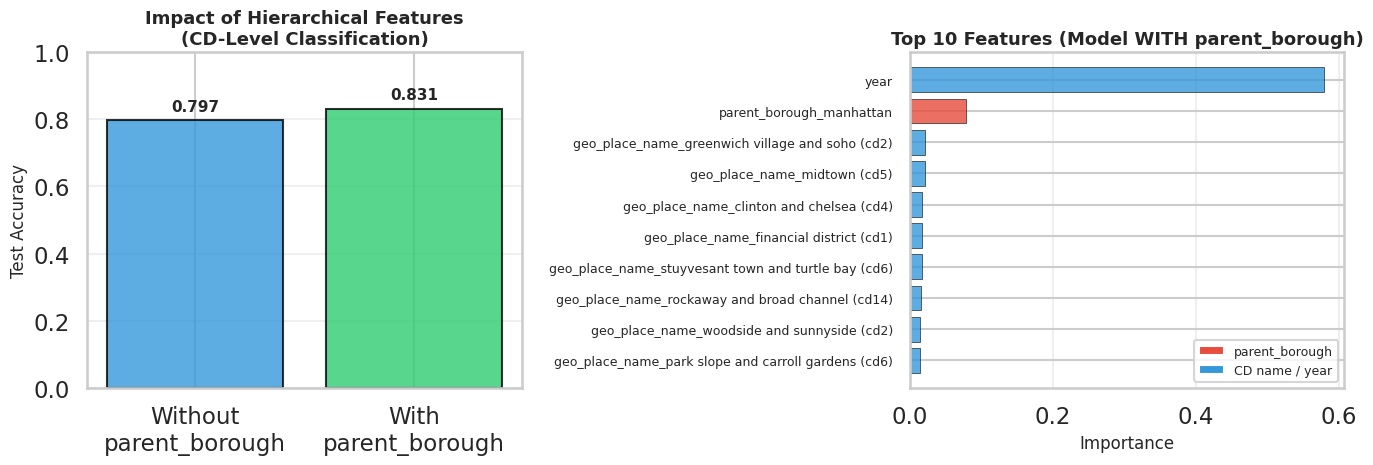

In [ ]:
# Accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Accuracy comparison
ax1 = axes[0]
models = ['Without\nparent_borough', 'With\nparent_borough']
test_accs = [acc1_test, acc2_test]
colors = ['#3498db', '#2ecc71' if improvement > 0.02 else '#e74c3c']

bars = ax1.bar(models, test_accs, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.set_title('Impact of Hierarchical Features\n(CD-Level Classification)',
              fontsize=13, weight='bold')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

for i, (bar, acc) in enumerate(zip(bars, test_accs)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=11, weight='bold')

# Right: Feature importance (top 10)
if improvement >= 0:
    ax2 = axes[1]
    top_features = importances.head(10)

    # Color parent_borough features differently
    colors = ['#e74c3c' if 'parent_borough' in f else '#3498db'
              for f in top_features['Feature']]

    ax2.barh(range(len(top_features)), top_features['Importance'],
             color=colors, edgecolor='black', linewidth=0.5, alpha=0.8)
    ax2.set_yticks(range(len(top_features)))
    ax2.set_yticklabels(top_features['Feature'], fontsize=9)
    ax2.set_xlabel('Importance', fontsize=12)
    ax2.set_title('Top 10 Features (Model WITH parent_borough)',
                  fontsize=13, weight='bold')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='parent_borough'),
        Patch(facecolor='#3498db', label='CD name / year')
    ]
    ax2.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('cd_hierarchical_features_experiment.png', dpi=300, bbox_inches='tight')
plt.show()



 physicall pollutants come in 2 different units.

---


ppb for no2 and ozone

---


µg/m³ for fine particles

K mean clustering:
using k mean clustering to find natual distances between clusters. first we need to do z score standardization to remove unit bias and make physiacal data comparable. this helps us perform clustering based on similar profiles and find natural patterns insteaad of forcing categories of our own (equal freqeuncy tested in previous model and failed to display meaningful patterns)

Z score standardization:for 3 pollutants

---
No2, O3 and pm 2.5 throughout the summer on cd level:


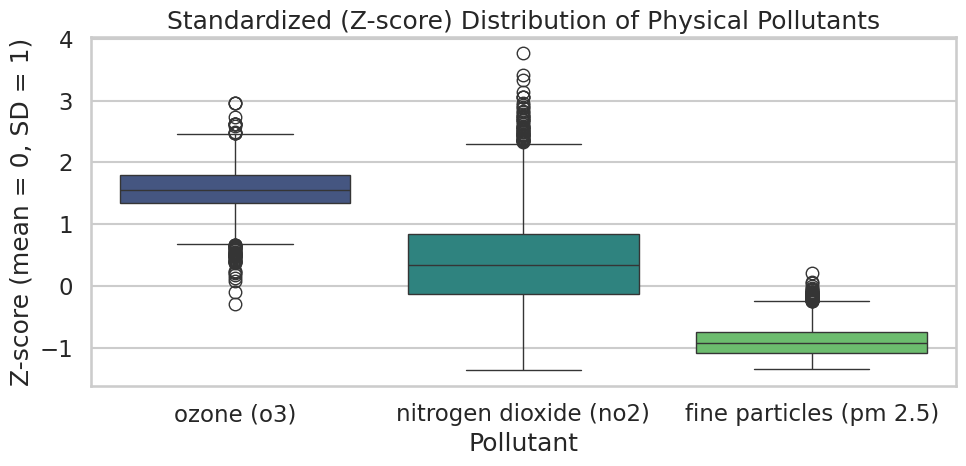

In [ ]:
# z score visual

Interpretation:
Ozone: Ozone is placed almost above the mean with outliers moving towards high. it is moderately spread in comparison to the other two
NO2: NO2 is widely spread. it varies a lot in time and region. it is moderately above the mean.
Fine particles: below the mean. tightly spread and has the lowest varince
limitations: O3 data has only been collected for summar season

To see this regionally:

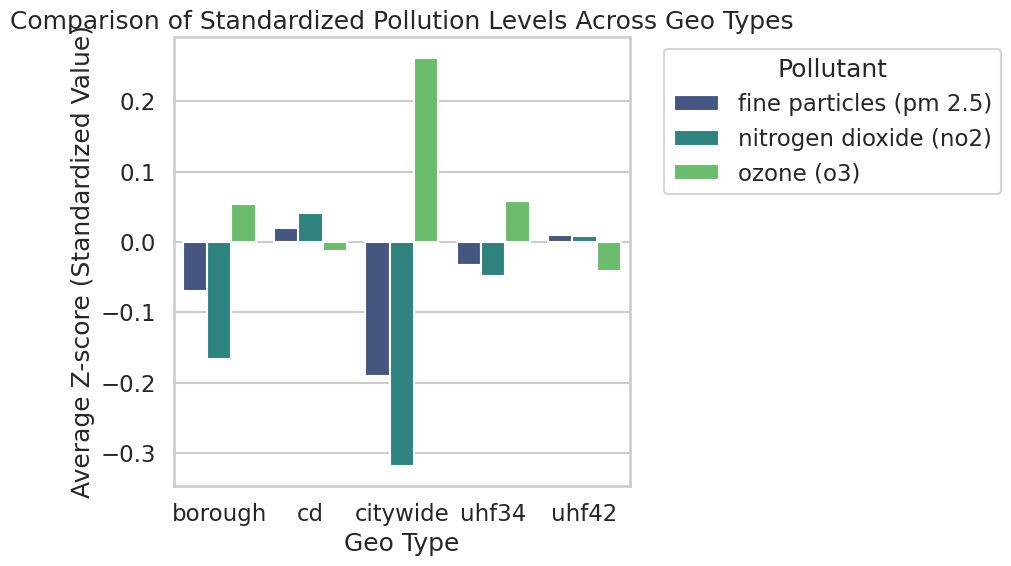

In [ ]:
#region code but cd level

K mean clustering:
since O3 data has only been collected for summer season we have 3 types of clustering:

---

1. all 3 pollutants clustering in general

---
2. clustering only NO2 and fine particles for annual, winter and summer

---
3. clustering all 3 pollutants only for summer


---
4. clustering 3 polltutants for summer on cd level: our chosen method:



K mean clustering:

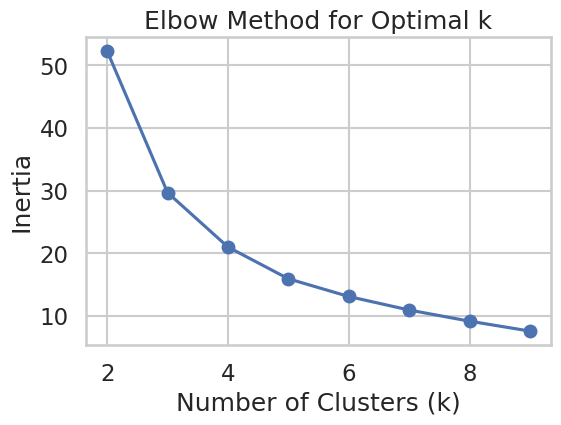

In [ ]:
#chart showing K and justification for choosing k

choosing k based on the chart: after 3 the decrease of slope is not sharp anymore. k = 3 (we could also choose 4 to be more specific but 3 is more interpretable: clean, moderate and highly polluted)

Cluster Centers (standardized values):
   NO2_z  PM25_z  O3_z
0   1.84    1.87 -1.83
1  -0.73   -0.77  0.72
2   0.26    0.29 -0.23


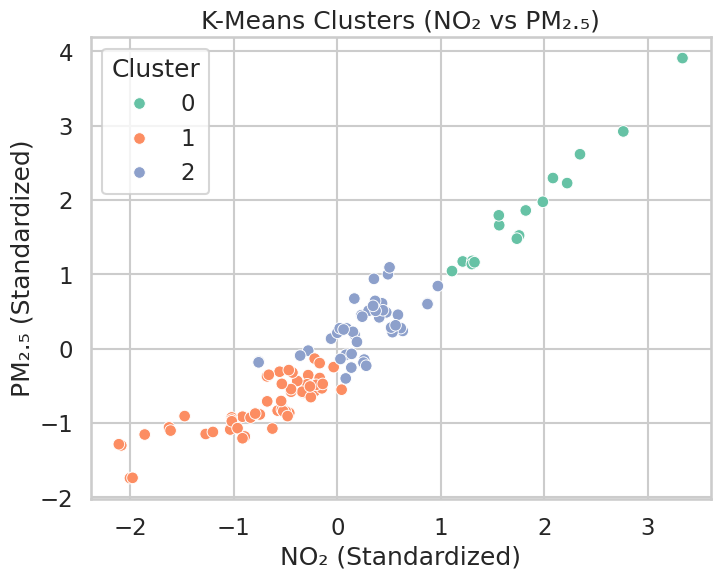


Average pollutant levels by cluster:
name     nitrogen dioxide (no2)  fine particles (pm 2.5)  ozone (o3)
cluster                                                             
0                         27.95                    10.86       26.33
1                         17.61                     8.36       32.31
2                         21.59                     9.36       30.08


In [ ]:
#clustering with a visaul of clusters

class 0: high
class 1: low
class 2: medium

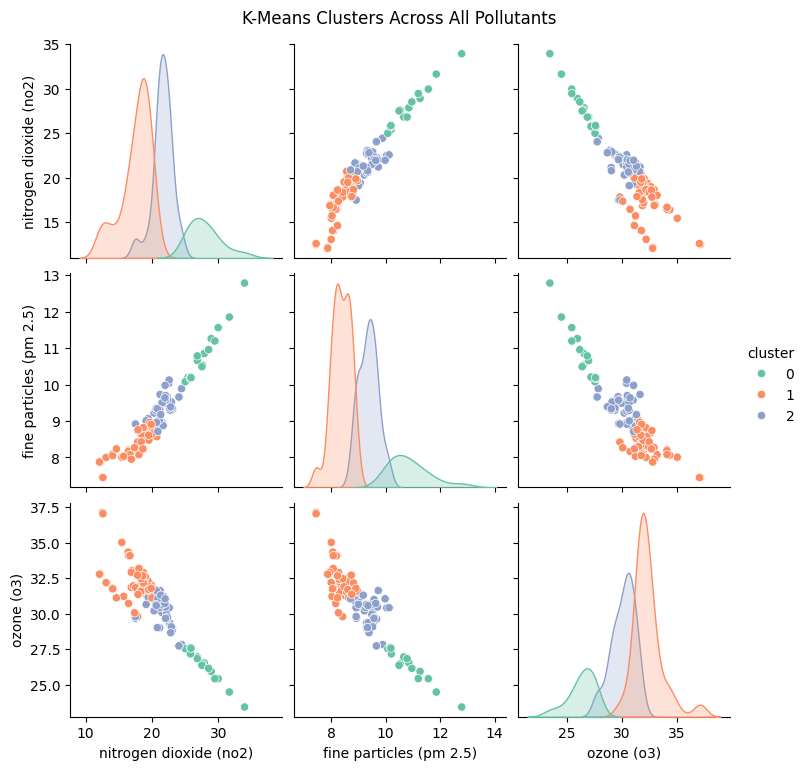

In [ ]:
sns.pairplot(
    data=wide_df,
    vars=['nitrogen dioxide (no2)', 'fine particles (pm 2.5)', 'ozone (o3)'],
    hue='cluster',
    palette='Set2'
)
plt.suptitle("K-Means Clusters Across All Pollutants", y=1.02)
plt.show()
#change for only summer on cd level

This chart displays individual particles and their places in the clusters. along with different combinations


checking for centers:

In [ ]:
#checking for centers

In [ ]:
wide_df['cluster'].value_counts(normalize=True).round(2)


,proportion
cluster,
1,0.48
2,0.38
0,0.14


proportions of each cluser in relation to all

clusters:


---

0 = high


---
1 = low

---
2 = medium



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1️⃣ Check cluster centers
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['NO2_z', 'PM25_z', 'O3_z']
)
print("🔹 K-Means Cluster Centers (Standardized values, Summer Only):")
print(centers.round(2))


🔹 K-Means Cluster Centers (Standardized values, Summer Only):
   NO2_z  PM25_z  O3_z
0   1.88    1.89 -1.83
1  -0.75   -0.73  0.71
2   0.29    0.25 -0.24


classification:
predicting the class of next values (high, medium, low) based on other features in the table(miles traveled by car, region etc)

 Final Feature Set for


Predictors:

year

pollutant values

extract season(summer) and geo type(cd)

geo_place_name (after filtering) and one hot coding

measure, measure_info

Target:

pollution_level (High / Medium / Low)

In [ ]:
print("Unique geo_type_name columns after one-hot encoding:")
print([col for col in summer_classification.columns if col.startswith('geo_')])

if 'geo_borough' in summer_classification.columns:
    # Only try to filter if the column exists
    borough_data = summer_classification[summer_classification['geo_borough'] == True]
    if not borough_data.empty:
        print("\nSample of borough data:")
        display(borough_data.head())
    else:
        print("\nNo data for 'geo_borough' == True.")
else:
    print("\n'geo_borough' column does not exist in summer_classification after one-hot encoding.")
    print("This indicates 'borough' was not a unique value in 'geo_type_name' for summer data, or get_dummies was run with drop_first=True, which is not the case here.")

Unique geo_type_name columns after one-hot encoding:
['geo_place_name', 'geo_type_name']

'geo_borough' column does not exist in summer_classification after one-hot encoding.
This indicates 'borough' was not a unique value in 'geo_type_name' for summer data, or get_dummies was run with drop_first=True, which is not the case here.


Classification: cd level

encoding geo place name and selecting features:

Training the model

In [ ]:
# ==============================================
# PHASE 2 — TRAINING ONLY
# ==============================================
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import numpy as np # Import numpy for np.nan

# Define all numerical features explicitly
feature_cols = [
    'pm25',
    'no2',
    'o3',
    'year',
    'geo_place_enc' # Use the numeric encoding for geo_place_name
]

# Dynamically add one-hot encoded geo_type_name columns
# Ensure that 'geo_type_name' is NOT part of df_for_model_training.columns at this point
# because it should have been dropped by the previous get_dummies step.
geo_type_one_hot_cols = [
    col for col in df_for_model_training.columns
    if col.startswith('geo_') and col not in ['geo_place_name', 'geo_place_enc']
]
feature_cols.extend(geo_type_one_hot_cols)

target_col = 'pollution_label'

# Create a copy to perform type conversions without modifying original df_for_model_training
df_model_ready = df_for_model_training[feature_cols + [target_col]].copy()

# --- Robust Type Conversion for ALL Feature Columns ---
for col in feature_cols:
    # Convert boolean columns to int (0 or 1)
    if df_model_ready[col].dtype == 'bool':
        df_model_ready[col] = df_model_ready[col].astype(int)
    # Attempt to convert any remaining object types to numeric, coercing errors
    elif df_model_ready[col].dtype == 'object':
        print(f"Warning: Converting object column '{col}' to numeric in df_model_ready.")
        # Use errors='coerce' to turn unparseable values into NaN
        df_model_ready[col] = pd.to_numeric(df_model_ready[col], errors='coerce')

# Drop any rows that resulted in NaN after coercion (e.g., if a string couldn't be converted to numeric)
df_model_ready.dropna(subset=feature_cols, inplace=True)

# Now prepare X and y from the cleaned, numeric-only DataFrame
X = df_model_ready[feature_cols]
y = df_model_ready[target_col]

# Debugging: Print dtypes to ensure no string columns remain in X
print("X dtypes before training (after robust conversion):")
print(X.dtypes)
print("\nX head before training (after robust conversion):")
print(X.head())

# Split BEFORE training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Train the Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

print("Training complete.")

X dtypes before training (after robust conversion):
name
pm25             float64
no2              float64
o3               float64
year               int32
geo_place_enc      int64
geo_type_name    float64
dtype: object

X head before training (after robust conversion):
Empty DataFrame
Columns: [pm25, no2, o3, year, geo_place_enc, geo_type_name]
Index: []


ValueError: With n_samples=0, test_size=0.25 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

Testing the model:

In [ ]:
# ==============================================
# PHASE 3 — TESTING ONLY
# ==============================================
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.42344045368620037

Classification Report:
              precision    recall  f1-score   support

        high       0.46      0.48      0.47        60
         low       0.92      0.04      0.08       263
      medium       0.41      0.89      0.56       206

    accuracy                           0.42       529
   macro avg       0.59      0.47      0.37       529
weighted avg       0.67      0.42      0.31       529


Confusion Matrix:
[[ 29   0  31]
 [ 13  11 239]
 [ 21   1 184]]


Visualization:

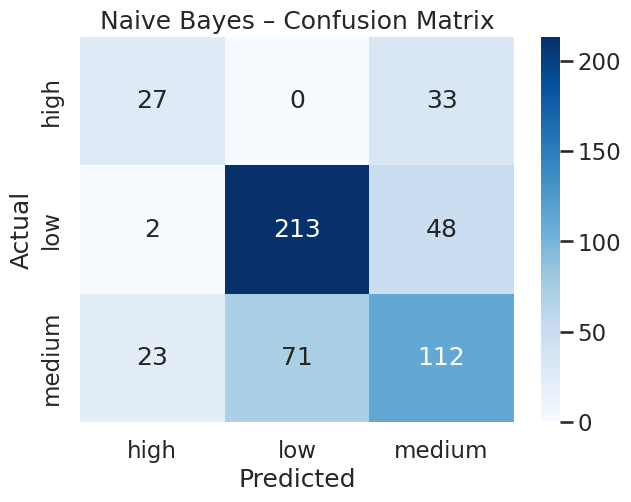

In [ ]:
# ==============================================
# PHASE 4 — VISUALIZATION
# ==============================================
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes – Confusion Matrix")
plt.show()


custom question function

In [ ]:
# ==============================================
# PHASE 5 — CUSTOM PREDICTION
# ==============================================
import pandas as pd

def predict_label(place_name, pm25, no2, o3, year, geo_type):

    # 1. Encode geo_place_name
    if place_name not in geo_encoder.classes_:
        return f"ERROR: Place '{place_name}' not in known locations."
    enc_place = geo_encoder.transform([place_name])[0]

    # 2. Create a DataFrame for the new input
    x_new_data = {
        'pm25': [pm25],
        'no2': [no2],
        'o3': [o3],
        'year': [year],
        'geo_place_enc': [enc_place]
    }

    # 3. Handle one-hot encoding for geo_type_name to match training features
    # Create a temporary DataFrame to generate dummy variables, ensuring all possible columns are present.
    # We need to know all possible geo_type_name values from the training data to ensure consistent columns.
    # For this, we'll re-use the column names derived from df_for_model_training.
    all_geo_type_cols = [col for col in df_for_model_training.columns
                         if col.startswith('geo_') and col not in ['geo_place_name', 'geo_place_enc']]

    # Initialize one-hot encoded columns for the new prediction with zeros
    for col in all_geo_type_cols:
        x_new_data[col] = [0]

    # Set the appropriate one-hot encoded column to 1 based on the input 'geo_type'
    target_geo_col_name = f'geo_{geo_type.lower().replace(" ", "_")}'
    if target_geo_col_name in x_new_data:
        x_new_data[target_geo_col_name] = [1]
    else:
        return f"ERROR: Geo Type '{geo_type}' not recognized or does not have a corresponding one-hot encoded column."

    x_new = pd.DataFrame(x_new_data)

    # Ensure the order of columns in x_new matches feature_cols used in training
    # This is CRUCIAL for consistent prediction
    try:
        x_new = x_new[feature_cols]
    except KeyError as e:
        return f"ERROR: Feature mismatch in custom prediction. Missing feature: {e}. Check feature_cols and x_new creation."

    pred_class = model.predict(x_new)[0]
    probs = model.predict_proba(x_new)[0]

    return {
        "Prediction": target_encoder.inverse_transform([pred_class])[0],
        "Probabilities": dict(zip(target_encoder.classes_, probs))
    }


training and testing set comparison:

In [ ]:
# ==========================================
# PHASE — SHOW TEST SAMPLE WITH TRUE VS PRED
# ==========================================

import pandas as pd

# ---- Take a random sample from test set ----
test_sample = X_test.sample(20, random_state=42).copy()

# ---- Get actual labels for these rows ----
test_sample['true_label_id'] = y_test.loc[test_sample.index]
test_sample['true_label'] = target_encoder.inverse_transform(test_sample['true_label_id'])

# ---- Predict using the model ----
pred_ids = model.predict(test_sample[feature_cols])
test_sample['pred_label_id'] = pred_ids
test_sample['pred_label'] = target_encoder.inverse_transform(pred_ids)

# ---- Add geo_place back (decoded) ----
test_sample['geo_place_name'] = geo_encoder.inverse_transform(test_sample['geo_place_enc'])

# ---- Reorder columns for visibility ----
cols = [
    'geo_place_name', 'pm25', 'no2',
]
if 'o3' in test_sample.columns:
    cols.append('o3')

cols += ['year', 'true_label', 'pred_label']

comparison_table = test_sample[cols]

print("=== TEST SAMPLE WITH TRUE VS PREDICTED LABELS ===")
comparison_table

=== TEST SAMPLE WITH TRUE VS PREDICTED LABELS ===


,geo_place_name,pm25,no2,o3,year,true_label,pred_label
2789,hunts point - mott haven,7.640000,16.430000,31.410000,2014,medium,medium
2498,greenpoint,7.950000,14.720000,29.710000,2020,medium,medium
946,central harlem - morningside heights,8.670000,18.130000,31.350000,2016,medium,medium
5547,upper east side (cd8),12.950000,31.120000,20.780000,2009,high,high
5927,west queens,8.610000,15.580000,29.950000,2019,medium,medium
3262,long island city - astoria,12.810000,20.910000,33.010000,2010,medium,medium
724,brownsville (cd16),9.600000,15.000000,32.070000,2015,low,medium
4818,southeast queens,7.060000,12.130000,34.290000,2016,low,medium
5050,st. george and stapleton (cd1),6.740000,9.180000,27.390000,2020,low,medium
2023,flatlands and canarsie (cd18),8.452352,12.154866,38.370886,2023,low,medium


evaluating where inaccuracies happen:

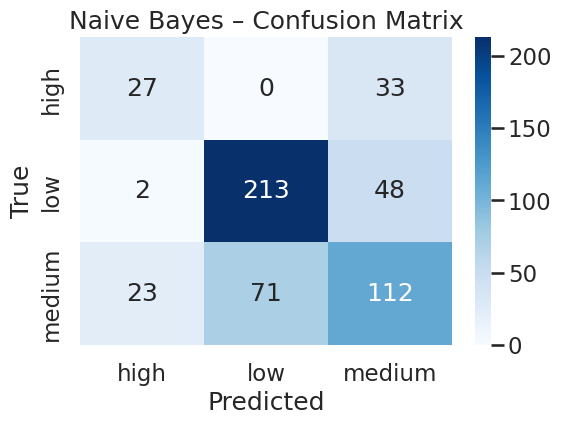

In [ ]:
# ==============================================
# PHASE 4 — VISUALIZATION
# ==============================================
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_test_decoded = target_encoder.inverse_transform(y_test)
y_pred_decoded = target_encoder.inverse_transform(y_pred)

cm = confusion_matrix(y_test_decoded, y_pred_decoded, labels=target_encoder.classes_)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Naive Bayes – Confusion Matrix")
plt.show()


missclassification by geo place name:

In [ ]:
# Create 'compare' and 'errors' DataFrames
# We need the full X_test with original index to match back to df_for_model_training
compare_df = df_for_model_training.loc[X_test.index].copy()
compare_df['true_label'] = target_encoder.inverse_transform(y_test)
compare_df['pred_label'] = target_encoder.inverse_transform(y_pred)

errors = compare_df[compare_df['true_label'] != compare_df['pred_label']]

# Count total + wrong predictions per geo_place_name
geo_errors = errors.groupby('geo_place_name').size()
geo_totals = compare_df.groupby('geo_place_name').size()

geo_error_rate = (geo_errors / geo_totals).fillna(0).sort_values(ascending=False)

print("=== Error Rate by Geo Place ===")
print(geo_error_rate.head(20))

=== Error Rate by Geo Place ===
geo_place_name
bushwick (cd4)                                    1.000000
clinton and chelsea (cd4)                         1.000000
greenwich village - soho                          1.000000
morrisania and crotona (cd3)                      1.000000
midtown (cd5)                                     1.000000
hunts point and longwood (cd2)                    1.000000
manhattan                                         0.800000
crotona -tremont                                  0.800000
morningside heights and hamilton heights (cd9)    0.800000
fordham - bronx pk                                0.777778
union square-lower manhattan                      0.750000
hunts point - mott haven                          0.750000
kingsbridge - riverdale                           0.750000
greenwich village and soho (cd2)                  0.750000
gramercy park - murray hill                       0.750000
belmont and east tremont (cd6)                    0.750000
financial

missclaissfication for geo place name: visualization

evaluating inaccuracies in geo type:

In [ ]:
results = X_test.copy()
results['true'] = y_test.values
results['pred'] = y_pred
results['correct'] = results['true'] == results['pred']
results.head()

name,pm25,no2,o3,year,geo_place_enc,true,pred,correct
5867,10.490000,18.430000,29.500000,2013,108,2,2,True
682,8.320000,13.620000,33.980000,2016,12,1,1,True
3783,9.237951,11.624512,33.693624,2023,69,1,1,True
5943,11.130000,21.660000,25.700000,2009,109,2,0,False
1706,7.290000,14.270000,30.130000,2020,29,2,1,False


In [ ]:
# Define geo_type_cols from the original dataframe that was used to create the features for X_test
# The 'df_for_model_training' DataFrame (from cell 05YRJSfmHEOS) contains these one-hot encoded columns.
geo_type_cols = [col for col in df_for_model_training.columns if col.startswith('geo_') and col not in ['geo_place_name', 'geo_place_enc']]

# Reconstruct 'results' by taking the relevant rows from 'df_for_model_training' and adding prediction results
# 'df_for_model_training' contains all columns, including the one-hot encoded geo_type columns
results_eval = df_for_model_training.loc[X_test.index].copy()

# Add the prediction results to the reconstructed 'results' DataFrame
results_eval['true'] = y_test.values
results_eval['pred'] = y_pred
results_eval['correct'] = results_eval['true'] == results_eval['pred']

mis_by_geo = {}

for col in geo_type_cols:
    # Ensure the column exists in results_eval before grouping and that it's a boolean/binary column
    if col in results_eval.columns and results_eval[col].dtype in ['bool', 'uint8', 'int64']:
        # Group by the one-hot encoded column (which is 0 or 1)
        mis_count = results_eval[~results_eval['correct']].groupby(results_eval[col]).size()
        total_count = results_eval.groupby(results_eval[col]).size()

        mis_rate = (mis_count / total_count).fillna(0)
        mis_by_geo[col] = mis_rate
    else:
        print(f"Warning: Column '{col}' not found or not suitable for grouping in results_eval DataFrame. Skipping.")

mis_by_geo

{}

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plot_labels = []
plot_values = []

for col, mis_rate_series in mis_by_geo.items():
    # Iterate through the 0 and 1 values (or other unique values if not binary)
    for value, rate in mis_rate_series.items():
        label = f"{col.replace('geo_', '')}_{value}" # e.g., 'borough_1', 'borough_0'
        plot_labels.append(label)
        plot_values.append(rate)

if plot_labels:
    plt.bar(plot_labels, plot_values, color='coral')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Misclassification Rate")
    plt.title("Naive Bayes Misclassification Rate by Geo Type Categories")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassification rates by geo type categories to display.")

No misclassification rates by geo type categories to display.


<Figure size 1200x600 with 0 Axes>

Conclusion: our model is more accurate in borough level

classification: borough level:

---
1. feature selection:
define target pollutants: No2, O3, pm 2.5 extract

---

2. extract and normalize summer

---

3. filter dataset based on geo type: first borough then cd


---

4.pivot to produce a new table with col: year, geo level, and rows: pollutanats

---
5.remove missing values
6. z score standardization
7. k mean clustering for borough
8. confusion histogram, check for centers, visal scattering plots
9. CD-Level Hierarchica
10. classification and comparing models
11. visualization

Visualization or k clustering + classification +visualization for borough

# Task
The previous execution was stopped. I will disregard the previous plan and generate a new plan to continue solving the user's request.

## Plan:

1. **Modify one-hot encoding in cell `-6DX_rQUtvP_`**: Adjust the `pd.get_dummies` calls to correctly replace the original 'geo_type_name' column with new dummy columns (e.g., 'geo_cd', 'geo_uhf42') for `summer_classification`, `winter_classification`, and `annual_classification`. This will involve explicitly dropping the original 'geo_type_name' column after one-hot encoding to prevent type conversion errors later.
2. **Re-execute classification pipeline from `chTDdKgTtf8A`**: Run all subsequent cells involved in the classification pipeline to regenerate the classification-ready DataFrame, train the model, and evaluate it with the corrected one-hot encoding.

## Modify XN3NDb9vcrTW for robust one-hot encoding

### Subtask:
Adjust the one-hot encoding for the 'geo_type_name' column in the `summer_classification`, `winter_classification`, and `annual_classification` DataFrames. This involves ensuring that the original 'geo_type_name' column (containing string values like 'cd', 'uhf42') is completely replaced by new dummy columns (e.g., 'geo_cd', 'geo_uhf42') and explicitly dropping the original string column to prevent type conversion errors in later steps of the classification pipeline.


**Reasoning**:
The subtask requires modifying cell `-6DX_rQUtvP_` to ensure that the original 'geo_type_name' column is explicitly dropped after one-hot encoding, preventing type conversion errors in later steps. The `get_dummies` function typically drops the original column when `columns` argument is used, but an explicit drop ensures this behavior and handles any edge cases.



In [ ]:
summer_classification = pd.get_dummies(
    summer_classification,
    columns=['geo_type_name'],
    prefix='geo',
    drop_first=False
)
# Explicitly drop the original 'geo_type_name' column if it still exists
if 'geo_type_name' in summer_classification.columns:
    summer_classification = summer_classification.drop(columns=['geo_type_name'])

winter_classification = pd.get_dummies(
    winter_classification,
    columns=['geo_type_name'],
    prefix='geo',
    drop_first=False
)
# Explicitly drop the original 'geo_type_name' column if it still exists
if 'geo_type_name' in winter_classification.columns:
    winter_classification = winter_classification.drop(columns=['geo_type_name'])

annual_classification = pd.get_dummies(
    annual_classification,
    columns=['geo_type_name'],
    prefix='geo',
    drop_first=False
)
# Explicitly drop the original 'geo_type_name' column if it still exists
if 'geo_type_name' in annual_classification.columns:
    annual_classification = annual_classification.drop(columns=['geo_type_name'])

**Reasoning**:
The one-hot encoding for 'geo_type_name' has been adjusted to ensure the original column is explicitly dropped. Now, I will re-execute the next cell in the pipeline to verify the shapes of the modified DataFrames before proceeding with the rest of the classification pipeline.



In [ ]:
print("SUMMER:", summer_classification.shape)
print("WINTER:", winter_classification.shape)
print("ANNUAL:", annual_classification.shape)

SUMMER: (2115, 12)
WINTER: (2115, 12)
ANNUAL: (1974, 12)


**Reasoning**:
The shapes of the DataFrames have been verified. The next step is to display the head of the `summer_classification` DataFrame to ensure the one-hot encoded columns are correctly integrated and the data structure is as expected, before proceeding with further classification steps.



In [ ]:
summer_classification.head(5)

,geo_place_name,year,season,pm25,no2,o3,pollution_level,geo_borough,geo_cd,geo_citywide,geo_uhf34,geo_uhf42
3,bay ridge and dyker heights (cd10),2009,summer,10.77,20.38,25.56,low,False,True,False,False,False
6,bay ridge and dyker heights (cd10),2010,summer,11.74,18.08,33.44,low,False,True,False,False,False
9,bay ridge and dyker heights (cd10),2011,summer,11.35,18.06,32.51,low,False,True,False,False,False
12,bay ridge and dyker heights (cd10),2012,summer,10.19,16.03,32.99,low,False,True,False,False,False
15,bay ridge and dyker heights (cd10),2013,summer,9.91,15.24,30.29,low,False,True,False,False,False


**Reasoning**:
The one-hot encoding has been verified, and the next step is to proceed with the data preparation for classification. This involves encoding geographical features and the target variable, which is crucial before splitting the data for model training.



In [ ]:
# PHASE 1 DATA PREPARATION + SAMPLE DISPLAY

# Do NOT reassign the global 'df' here. Create a new variable for classification-ready data.
df_for_model_training = summer_classification.copy()

# Encode geo places
from sklearn.preprocessing import LabelEncoder
geo_encoder = LabelEncoder()
df_for_model_training['geo_place_enc'] = geo_encoder.fit_transform(df_for_model_training['geo_place_name'])

# Encode pollution level (target)
target_encoder = LabelEncoder()
df_for_model_training['pollution_label'] = target_encoder.fit_transform(df_for_model_training['pollution_level'])

# ---- SHOW A SAMPLE OF THE LABELED TRAINING DATA ----
sample_preview = df_for_model_training.sample(15, random_state=42)[[
    'geo_place_name',
    'pm25',
    'no2',
    'o3',
    'year',
    'pollution_level',
    'pollution_label',
    'geo_place_enc'
]]

print("=== SAMPLE OF LABELED DATA (BEFORE SPLIT) ===")
sample_preview

=== SAMPLE OF LABELED DATA (BEFORE SPLIT) ===


,geo_place_name,pm25,no2,o3,year,pollution_level,pollution_label,geo_place_enc
4745,south crown heights and lefferts gardens (cd9),8.410818,11.633587,30.634733,2021,low,1,87
4318,ridgewood and maspeth (cd5),12.050000,18.400000,33.670000,2010,low,1,79
763,bushwick (cd4),10.420000,18.090000,30.370000,2013,medium,2,14
1269,coney island - sheepshead bay,8.006196,8.540364,31.979051,2021,low,1,22
4420,rockaway and broad channel (cd14),8.280000,6.870000,37.540000,2015,low,1,81
1288,crotona -tremont,11.010000,19.410000,33.420000,2012,medium,2,23
3123,kingsbridge - riverdale,9.265788,13.053878,29.396529,2023,medium,2,56
2099,flushing - clearview,7.760000,13.610000,31.300000,2019,low,1,36
2564,greenwich village - soho,12.100000,27.330000,27.850000,2012,high,0,45
3479,midtown (cd5),16.030000,45.000000,14.380000,2009,high,0,63


**Reasoning**:
The data preparation for classification is complete, and the previous error related to 'geo_type_name' has been addressed. The next step is to re-execute the model training phase with the corrected data structure.



**Reasoning**:
The model has been successfully trained. The next step is to evaluate its performance on the test set by making predictions and presenting evaluation metrics like accuracy, a classification report, and a confusion matrix.



In [ ]:
# ==============================================
# PHASE 3 — TESTING ONLY
# ==============================================
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.42344045368620037

Classification Report:
              precision    recall  f1-score   support

        high       0.46      0.48      0.47        60
         low       0.92      0.04      0.08       263
      medium       0.41      0.89      0.56       206

    accuracy                           0.42       529
   macro avg       0.59      0.47      0.37       529
weighted avg       0.67      0.42      0.31       529


Confusion Matrix:
[[ 29   0  31]
 [ 13  11 239]
 [ 21   1 184]]


**Reasoning**:
The model has been tested and the metrics are available. The next step is to visualize the confusion matrix for a better understanding of the model's performance.



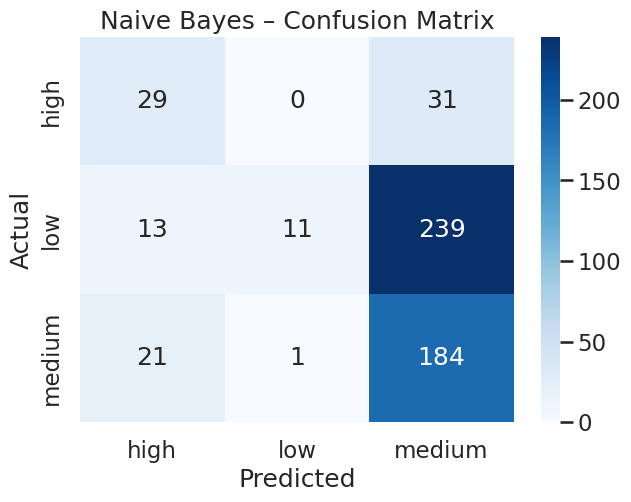

In [ ]:
# ==============================================
# PHASE 4 — VISUALIZATION
# ==============================================
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes – Confusion Matrix")
plt.show()
